**Explainable Medical (EM)-LLM: Data Extraction, Merging & Cohort Selection**   
**Presented by: Reza Saadatyar (2026-2027)**   
*E-mail: Reza.Saadatyar92@gmail.com*

**Objective: Data Extraction, Temporal Linking, and Cohort Construction for EM-LLM**

The objective of this notebook is to construct the foundational multimodal cohort for the Explainable Medical LLM pipeline. This notebook links Emergency Department clinical records from MIMIC-IV-ED with MIMIC-CXR metadata, applies encounter-level temporal constraints, attaches hospital outcome labels, and exports a cleaned cohort that can be reused by all downstream notebooks.

This notebook does not perform text preprocessing, image-path construction, model training, or evaluation. Instead, it defines the core patient-study population, validates key identifiers, compares linkage strategies, applies outcome governance, and creates a reproducible cohort index for later clinical text, imaging, instruction-generation, fine-tuning, and evaluation stages.

**Expected Main Outputs**  
The main outputs of this notebook include:

`cohort_final_selected.csv`  
The selected cohort after strategy comparison and Gate-0 reproducibility checks.

`cohort_final_selected_observed.csv`  
The supervised subset containing records with observed hospital outcome labels.

`cohort_merged.csv`  
The backward-compatible final cohort export used by downstream notebooks.

`cohort_merged_cleaned.csv`  
The standardized cleaned version of the final cohort after missingness handling and imputation.

`cohort_final_selected_cleaning_report.json`  
A structured cleaning and missing-data audit report.

`multitask_readiness_board_01.json`  
A preliminary downstream-readiness audit for CPLLM, MedTVT, PointDetectCount, and xHAIM contract preparation.

**Preliminary Setup: Library Import, Project Path Registration, and Hardware Verification**

This setup prepares the notebook environment before cohort construction begins. It imports the required libraries, registers the project root for access to local `src` utilities, applies a consistent plotting style, and verifies the available computation hardware.

In [ ]:
# =====================================================================
# Imported Libraries (categorized)
# =====================================================================

# ---------------------------------------------------------
# Standard Library
# ---------------------------------------------------------
import sys
import os

# Add project root to sys.path to resolve 'src' imports
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import re
import json
import zipfile
from pathlib import Path
from datetime import datetime, timezone
from typing import Any, Dict, List, Tuple
from dataclasses import dataclass, asdict, field

# ---------------------------------------------------------
# Core Data and Visualization
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# ML / PyTorch / LLM Pipeline
# ---------------------------------------------------------
from sklearn.impute import SimpleImputer

# ---------------------------------------------------------
# Project Utilities
# ---------------------------------------------------------
from src.utils.hardware_verification import verify_hardware

# Global Plot Style Configuration
mpl.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   12.5,
    "axes.titleweight": "normal",
    "axes.labelsize":   11.5,
    "axes.labelweight": "normal",
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  10,
    "figure.dpi":       100,
})

print("Libraries imported and academic plotting style successfully applied.")

# Global Device Configuration for PyTorch
device = verify_hardware()
print(f"Global Computation Device Set To: {device}")


Libraries imported and academic plotting style successfully applied.
⏳ Initializing hardware verification protocol...

🖥️ OS: Windows 11 | CPU: Intel64 Family 6 Model 151 Stepping 2, GenuineIntel | RAM: 31.7 GB

✅ GPU Accelerator detected successfully.
🎮 Hardware Device: NVIDIA GeForce RTX 3090
💾 Total VRAM Allocated: 24.00 GB
🚀 System is fully optimized and ready for heavy tensor operations.

🔧 PyTorch Version: 2.6.0+cu124
✅ PyTorch CUDA is available.
   Device Name : NVIDIA GeForce RTX 3090
   CUDA Version: 12.4
   cuDNN Version: 90100
   VRAM (PyTorch): 24.00 GB
   Selected Device: cuda
Global Computation Device Set To: cuda


**Step 1: Dataset Path Validation, Selective Loading, and Initial Quality Check**

This step validates the local dataset structure and loads the minimum raw tables required to begin cohort construction. The notebook checks the availability of MIMIC-IV-ED stays, ED triage records, and MIMIC-CXR metadata before reading them into memory with controlled column selection and explicit data types.

**Main Operations**  
◽ Define the local dataset root and source-specific folders for MIMIC-IV-ED, MIMIC-CXR, and MIMIC-IV hospital data  
◽ Validate the required raw files before loading any tables  
◽ Load ED stay records with encounter timing, admission linkage, and ED disposition fields  
◽ Load ED triage records with vital signs and chief complaint information  
◽ Load CXR metadata with `dicom_id`, `study_id`, view position, study date, and study time  
◽ Construct a unified `cxr_datetime` field from CXR study date and time values  
◽ Generate initial quality profiles for missing identifiers and duplicate records  

**Technical and Clinical Significance**  
Selective loading reduces memory usage and keeps the cohort-building step focused on the fields required for linkage. Validating files before loading prevents silent path errors, while explicit data types improve reproducibility across notebook reruns. Creating `cxr_datetime` at this stage is essential because later ED-CXR linkage depends on temporal alignment between ED encounter windows and imaging study times.

Clinically, this step establishes the raw sources needed to connect ED presentation data with chest X-ray studies. The initial quality checks help identify missing identifiers or duplicated keys before any patient, encounter, or imaging linkage is attempted.

**Expected Outcome**  
Three validated source dataframes are available: `df_edstays`, `df_triage`, and `df_cxr_meta`. The CXR metadata also contains a parsed `cxr_datetime` column, and the notebook has completed initial structural quality checks for the main identifier fields.

In [ ]:
# =====================================================================
# Step 1: Dataset Path Validation, Selective Loading, and Initial Quality Check
# =====================================================================

print("Step 1: Dataset Path Validation, Selective Loading, and Initial Quality Check...")

# ---------------------------------------------------------
# 1) Base paths
# ---------------------------------------------------------
BASE_DIR = Path.home() / "OneDrive - hull.ac.uk" / "Explainable Medical LLM Dataset" / "datasets"
PATH_ED = BASE_DIR / "mimic-iv-ed"
PATH_CXR = BASE_DIR / "mimic_cxr"
PATH_HOSP = BASE_DIR / "mimic-iv" / "hosp"
ED_SUBFOLDER = PATH_ED / "ed"

# Required files for this stage
required_files = {
    "ED stays": ED_SUBFOLDER / "edstays.csv.gz",
    "ED triage": ED_SUBFOLDER / "triage.csv.gz",
    "CXR metadata": PATH_CXR / "mimic-cxr-2.0.0-metadata.csv.gz",
}

print(f"Dataset root: {BASE_DIR}")

# ---------------------------------------------------------
# 2) Validate paths and files (fail fast)
# ---------------------------------------------------------
missing = [name for name, p in required_files.items() if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required dataset file(s): "
        + ", ".join(missing)
        + ". Please verify local paths and extracted datasets."
    )

print("All required files are available.")

# ---------------------------------------------------------
# 3) Reusable CSV reader
# ---------------------------------------------------------
def read_gzip_csv(file_path, usecols, dtype=None, parse_dates=None):
    return pd.read_csv(
        file_path,
        compression="gzip",
        usecols=usecols,
        dtype=dtype,
        parse_dates=parse_dates
    )

# ---------------------------------------------------------
# 4) Load ED stays
# ---------------------------------------------------------
print("\nLoading ED stays...")
edstays_cols = ["subject_id", "hadm_id", "stay_id", "intime", "outtime", "disposition"]
edstays_dtypes = {
    "subject_id": "Int64",
    "hadm_id": "Int64",
    "stay_id": "Int64",
    "disposition": "string",
}
df_edstays = read_gzip_csv(
    required_files["ED stays"],
    usecols=edstays_cols,
    dtype=edstays_dtypes,
    parse_dates=["intime", "outtime"]
)
print(f"ED stays loaded: {len(df_edstays):,} rows")

# ---------------------------------------------------------
# 5) Load ED triage
# ---------------------------------------------------------
print("\nLoading ED triage...")
triage_cols = [
    "subject_id", "stay_id", "temperature", "heartrate", "resprate",
    "o2sat", "sbp", "dbp", "chiefcomplaint"
]
triage_dtypes = {
    "subject_id": "Int64",
    "stay_id": "Int64",
    "temperature": "float32",
    "heartrate": "float32",
    "resprate": "float32",
    "o2sat": "float32",
    "sbp": "float32",
    "dbp": "float32",
    "chiefcomplaint": "string",
}
df_triage = read_gzip_csv(
    required_files["ED triage"],
    usecols=triage_cols,
    dtype=triage_dtypes
)
print(f"ED triage loaded: {len(df_triage):,} rows")

# ---------------------------------------------------------
# 6) Load CXR metadata
# ---------------------------------------------------------
print("\nLoading CXR metadata...")
cxr_cols = ["dicom_id", "subject_id", "study_id", "ViewPosition", "StudyDate", "StudyTime"]
cxr_dtypes = {
    "dicom_id": "string",
    "subject_id": "Int64",
    "study_id": "Int64",
    "ViewPosition": "string",
    "StudyDate": "string",
    "StudyTime": "string",
}
df_cxr_meta = read_gzip_csv(
    required_files["CXR metadata"],
    usecols=cxr_cols,
    dtype=cxr_dtypes
)
print(f"CXR metadata loaded: {len(df_cxr_meta):,} rows")

# Build a robust CXR datetime for downstream temporal alignment
# StudyDate is expected as YYYYMMDD; StudyTime may include decimals.
# .astype("string") ensures safe accessor use on nullable string columns.
study_date = df_cxr_meta["StudyDate"].astype("string").str.zfill(8)
study_time = (
    df_cxr_meta["StudyTime"]
    .astype("string")
    .fillna("000000")
    .str.split(".")
    .str[0]
    .str.zfill(6)
)
df_cxr_meta["cxr_datetime"] = pd.to_datetime(
    study_date + study_time,
    format="%Y%m%d%H%M%S",
    errors="coerce"
)

# ---------------------------------------------------------
# 7) Initial quality profile
# ---------------------------------------------------------
def quick_quality_report(df, name, id_cols):
    print(f"\n{name} quality profile:")
    print(f"- Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    for col in id_cols:
        if col in df.columns:
            miss_pct = (df[col].isna().mean() * 100.0)
            print(f"- Missing {col}: {miss_pct:.2f}%")
    if all(c in df.columns for c in id_cols):
        dup = df.duplicated(subset=id_cols).sum()
        print(f"- Duplicates on {id_cols}: {dup:,}")

quick_quality_report(df_edstays, "ED stays", ["subject_id", "stay_id"])
quick_quality_report(df_triage, "ED triage", ["subject_id", "stay_id"])
quick_quality_report(df_cxr_meta, "CXR metadata", ["subject_id", "dicom_id"])

print("\nData loading and structural validation complete.")


Initializing local Windows path configuration and dataset validation...
Dataset root: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets
All required files are available.

Loading ED stays...
ED stays loaded: 425,087 rows

Loading ED triage...
ED triage loaded: 425,087 rows

Loading CXR metadata...
CXR metadata loaded: 377,110 rows

ED stays quality profile:
- Shape: 425,087 rows x 6 columns
- Missing subject_id: 0.00%
- Missing stay_id: 0.00%
- Duplicates on ['subject_id', 'stay_id']: 0

ED triage quality profile:
- Shape: 425,087 rows x 9 columns
- Missing subject_id: 0.00%
- Missing stay_id: 0.00%
- Duplicates on ['subject_id', 'stay_id']: 0

CXR metadata quality profile:
- Shape: 377,110 rows x 7 columns
- Missing subject_id: 0.00%
- Missing dicom_id: 0.00%
- Duplicates on ['subject_id', 'dicom_id']: 0

Data loading and structural validation complete.


**Step 2.1: Dual Cohort Construction with Baseline and Temporal-Strict Linkage**

This step builds two ED-CXR cohort strategies for comparison. The baseline strategy links ED encounters to CXR studies at the patient level, while the temporal-strict strategy keeps only CXR studies that fall within a clinically defined ED encounter window.

**Main Operations**  
◽ Build an ED encounter timeline using `intime` and `outtime`  
◽ Merge ED stays with triage records to create an encounter-level clinical table  
◽ Construct a baseline subject-level ED-CXR linkage strategy  
◽ Select one deterministic CXR study per ED stay for the baseline strategy  
◽ Construct a temporal-strict linkage strategy using ED encounter time windows  
◽ Audit whether CXR timestamps occur before, during, or after ED windows  
◽ Report cohort size and coverage for both linkage strategies  

**Technical and Clinical Significance**  
Direct subject-level linkage can connect a patient’s ED visit to a CXR study from a different clinical episode. The temporal-strict strategy reduces this risk by requiring imaging to align with the ED encounter window. Comparing both strategies makes the cohort-selection decision explicit rather than hidden inside a single merge operation.

**Expected Outcome**  
Two candidate multimodal cohorts are created: a broad baseline cohort and a stricter temporally aligned cohort. These outputs are used in later steps for outcome attachment, quality comparison, and final cohort selection.

In [ ]:
# =====================================================================
# Step 2.1: Dual cohort construction with temporal constraints
# =====================================================================

print("Step 2.1: Dual cohort construction with temporal constraints...")

# ---------------------------------------------------------
# 0) Preconditions
# ---------------------------------------------------------
required_objects = ["df_triage", "df_edstays", "df_cxr_meta"]
missing_objects = [x for x in required_objects if x not in globals()]
if missing_objects:
    raise RuntimeError(f"Missing required dataframes: {missing_objects}")

# Ensure datetime columns exist in ED table
if "intime" not in df_edstays.columns or "outtime" not in df_edstays.columns:
    raise ValueError("df_edstays must include intime and outtime columns.")

if not pd.api.types.is_datetime64_any_dtype(df_edstays["intime"]):
    df_edstays["intime"] = pd.to_datetime(df_edstays["intime"], errors="coerce")
if not pd.api.types.is_datetime64_any_dtype(df_edstays["outtime"]):
    df_edstays["outtime"] = pd.to_datetime(df_edstays["outtime"], errors="coerce")

# Ensure CXR datetime exists
if "cxr_datetime" not in df_cxr_meta.columns:
    study_date = df_cxr_meta["StudyDate"].astype("string").str.zfill(8)
    study_time = (
        df_cxr_meta["StudyTime"]
        .astype("string")
        .fillna("000000")
        .str.split(".")
        .str[0]
        .str.zfill(6)
    )
    df_cxr_meta["cxr_datetime"] = pd.to_datetime(
        study_date + study_time,
        format="%Y%m%d%H%M%S",
        errors="coerce"
    )

# ---------------------------------------------------------
# 1) ED encounter timeline
# ---------------------------------------------------------
ed_cols = ["subject_id", "stay_id", "hadm_id", "intime", "outtime", "disposition"]
ed_cols = [c for c in ed_cols if c in df_edstays.columns]

df_ed_timeline = pd.merge(
    df_triage,
    df_edstays[ed_cols],
    on=["subject_id", "stay_id"],
    how="inner"
).drop_duplicates(subset=["subject_id", "stay_id"], keep="first")

print(f"ED encounters prepared: {len(df_ed_timeline):,}")

cxr_cols = ["subject_id", "dicom_id", "study_id", "ViewPosition", "StudyDate", "StudyTime", "cxr_datetime"]
cxr_cols = [c for c in cxr_cols if c in df_cxr_meta.columns]

# ---------------------------------------------------------
# 2) Baseline strategy (subject-level linkage)
# ---------------------------------------------------------
df_baseline_candidates = pd.merge(
    df_ed_timeline,
    df_cxr_meta[cxr_cols],
    on="subject_id",
    how="inner"
)

# Deterministic one-CXR-per-stay selection for fair downstream comparison
# Baseline rule: earliest available CXR timestamp per stay
df_baseline_candidates = df_baseline_candidates[df_baseline_candidates["cxr_datetime"].notna()].copy()
df_baseline_candidates = df_baseline_candidates.sort_values(
    by=["subject_id", "stay_id", "cxr_datetime", "dicom_id"]
)
df_multimodal_baseline = df_baseline_candidates.drop_duplicates(
    subset=["subject_id", "stay_id"],
    keep="first"
).copy()

# ---------------------------------------------------------
# 3) Temporal-strict strategy
# ---------------------------------------------------------
PRE_HOURS = 6
POST_HOURS = 24

df_temporal_candidates_merged = pd.merge(
    df_ed_timeline,
    df_cxr_meta[cxr_cols],
    on="subject_id",
    how="inner"
)

valid_temporal_mask = (
    df_temporal_candidates_merged["cxr_datetime"].notna()
    & df_temporal_candidates_merged["intime"].notna()
    & df_temporal_candidates_merged["outtime"].notna()
)

n_temporal_missing_time = int((~valid_temporal_mask).sum())

df_temporal_candidates_raw = df_temporal_candidates_merged.loc[valid_temporal_mask].copy()
df_temporal_candidates_raw["window_start"] = df_temporal_candidates_raw["intime"] - pd.Timedelta(hours=PRE_HOURS)
df_temporal_candidates_raw["window_end"] = df_temporal_candidates_raw["outtime"] + pd.Timedelta(hours=POST_HOURS)

df_temporal_candidates_raw["signed_delta_hours"] = (
    (df_temporal_candidates_raw["cxr_datetime"] - df_temporal_candidates_raw["intime"]).dt.total_seconds() / 3600.0
)
df_temporal_candidates_raw["time_delta_minutes"] = (
    (df_temporal_candidates_raw["cxr_datetime"] - df_temporal_candidates_raw["intime"])
    .abs()
    .dt.total_seconds() / 60.0
)

df_temporal_candidates_raw["temporal_relation"] = np.select(
    [
        df_temporal_candidates_raw["cxr_datetime"] < df_temporal_candidates_raw["window_start"],
        df_temporal_candidates_raw["cxr_datetime"] > df_temporal_candidates_raw["window_end"],
    ],
    ["pre_window", "post_window"],
    default="in_window",
)

df_temporal_candidates = df_temporal_candidates_raw[
    df_temporal_candidates_raw["temporal_relation"] == "in_window"
].copy()

df_temporal_candidates = df_temporal_candidates.sort_values(
    by=["subject_id", "stay_id", "time_delta_minutes", "cxr_datetime", "dicom_id"]
)

df_multimodal_temporal = df_temporal_candidates.drop_duplicates(
    subset=["subject_id", "stay_id"],
    keep="first"
).copy()

# ---------------------------------------------------------
# 4) Temporal window audit
# ---------------------------------------------------------
temporal_relation_counts = (
    df_temporal_candidates_raw["temporal_relation"]
    .value_counts()
    .reindex(["pre_window", "in_window", "post_window"], fill_value=0)
)

df_temporal_window_audit = pd.DataFrame([
    {
        "raw_candidates_total": int(len(df_temporal_candidates_merged)),
        "valid_time_candidates": int(len(df_temporal_candidates_raw)),
        "missing_time_candidates": n_temporal_missing_time,
        "pre_window_candidates": int(temporal_relation_counts.get("pre_window", 0)),
        "in_window_candidates": int(temporal_relation_counts.get("in_window", 0)),
        "post_window_candidates": int(temporal_relation_counts.get("post_window", 0)),
        "pre_hours": PRE_HOURS,
        "post_hours": POST_HOURS,
    }
])

if "BASE_DIR" in globals():
    quality_dir = BASE_DIR / "quality_reports"
    quality_dir.mkdir(parents=True, exist_ok=True)
    temporal_window_audit_path = quality_dir / "temporal_window_audit.csv"
    df_temporal_window_audit.to_csv(temporal_window_audit_path, index=False)
else:
    temporal_window_audit_path = None

# ---------------------------------------------------------
# 5) Summary and coverage reporting
# ---------------------------------------------------------
baseline_coverage = (
    df_multimodal_baseline["stay_id"].nunique() /
    df_ed_timeline["stay_id"].nunique()
) * 100.0

temporal_coverage = (
    df_multimodal_temporal["stay_id"].nunique() /
    df_ed_timeline["stay_id"].nunique()
) * 100.0

print("\nDual cohort build complete.")
print(f"- Baseline candidates: {len(df_baseline_candidates):,}")
print(f"- Baseline primary cohort: {len(df_multimodal_baseline):,}")
print(f"- Temporal raw candidates: {len(df_temporal_candidates_merged):,}")
print(f"- Temporal valid-time candidates: {len(df_temporal_candidates_raw):,}")
print(f"- Temporal candidates (windowed): {len(df_temporal_candidates):,}")
print(f"- Temporal primary cohort: {len(df_multimodal_temporal):,}")
print(f"- Baseline unique patients: {df_multimodal_baseline['subject_id'].nunique():,}")
print(f"- Temporal unique patients: {df_multimodal_temporal['subject_id'].nunique():,}")
print(f"- Baseline ED stay coverage: {baseline_coverage:.2f}%")
print(f"- Temporal ED stay coverage: {temporal_coverage:.2f}%")
if temporal_window_audit_path is not None:
    print(f"- Temporal window audit saved: {temporal_window_audit_path}")

display(df_temporal_window_audit)
display(df_multimodal_baseline.head(3))
display(df_multimodal_temporal.head(3))


Building dual cohorts: baseline and temporal-strict...
ED encounters prepared: 425,087

Dual cohort build complete.
- Baseline candidates: 2,379,045
- Baseline primary cohort: 212,272
- Temporal raw candidates: 2,379,045
- Temporal valid-time candidates: 2,379,045
- Temporal candidates (windowed): 188,374
- Temporal primary cohort: 89,747
- Baseline unique patients: 61,856
- Temporal unique patients: 52,766
- Baseline ED stay coverage: 49.94%
- Temporal ED stay coverage: 21.11%
- Temporal window audit saved: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\temporal_window_audit.csv


,raw_candidates_total,valid_time_candidates,missing_time_candidates,pre_window_candidates,in_window_candidates,post_window_candidates,pre_hours,post_hours
0,2379045,2379045,0,1300808,188374,889863,6,24


,subject_id,stay_id,temperature,heartrate,resprate,o2sat,sbp,dbp,chiefcomplaint,hadm_id,intime,outtime,disposition,dicom_id,study_id,ViewPosition,StudyDate,StudyTime,cxr_datetime
0,10000032,32952584,97.800003,87.0,14.0,97.0,71.0,43.0,Hypotension,29079034,2180-07-22 16:24:00,2180-07-23 05:54:00,HOME,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,50414267,PA,21800506,213014.53100000002,2180-05-06 21:30:14
7,10000032,33258284,98.400002,70.0,16.0,97.0,106.0,63.0,"Abd pain, Abdominal distention",22595853,2180-05-06 19:17:00,2180-05-06 23:30:00,ADMITTED,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,50414267,PA,21800506,213014.53100000002,2180-05-06 21:30:14
14,10000032,35968195,99.400002,105.0,18.0,96.0,106.0,57.0,"n/v/d, Abd pain",25742920,2180-08-05 20:58:00,2180-08-06 01:44:00,ADMITTED,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,50414267,PA,21800506,213014.53100000002,2180-05-06 21:30:14


,subject_id,stay_id,temperature,heartrate,resprate,o2sat,sbp,dbp,chiefcomplaint,hadm_id,...,study_id,ViewPosition,StudyDate,StudyTime,cxr_datetime,window_start,window_end,signed_delta_hours,time_delta_minutes,temporal_relation
4,10000032,32952584,97.800003,87.0,14.0,97.0,71.0,43.0,Hypotension,29079034,...,53911762,AP,21800723,80556.875,2180-07-23 08:05:56,2180-07-22 10:24:00,2180-07-24 05:54:00,15.698889,941.933333,in_window
7,10000032,33258284,98.400002,70.0,16.0,97.0,106.0,63.0,"Abd pain, Abdominal distention",22595853,...,50414267,PA,21800506,213014.53100000002,2180-05-06 21:30:14,2180-05-06 13:17:00,2180-05-07 23:30:00,2.220556,133.233333,in_window
20,10000032,35968195,99.400002,105.0,18.0,96.0,106.0,57.0,"n/v/d, Abd pain",25742920,...,56699142,AP,21800805,234424.765,2180-08-05 23:44:24,2180-08-05 14:58:00,2180-08-07 01:44:00,2.773333,166.400000,in_window


**Step 2.2: Temporal Alignment and Linkage Multiplicity Diagnostics**

This step audits how ED encounters are linked to CXR studies under the two cohort-construction strategies. It summarizes whether CXR studies occur before, during, or after the ED window and evaluates how many candidate CXR studies are linked to each ED stay.

**Main Operations**  
◽ Summarize CXR timing relative to ED encounter windows  
◽ Count linkage multiplicity for baseline and temporal-strict candidate sets  
◽ Visualize temporal-relation and candidate-count distributions  
◽ Export diagnostic tables and figures for cohort-linkage review  

**Technical and Clinical Significance**  
Temporal diagnostics help detect whether the linkage strategy is clinically plausible. Linkage multiplicity is also important because many CXR studies can belong to the same patient or encounter, and uncontrolled multiplicity can bias downstream dataset construction.

**Expected Outcome**  
Temporal-linkage diagnostic tables and plots are generated, supporting transparent comparison between the baseline and temporal-strict cohort strategies.

Generating temporal alignment diagnostics and linkage visuals...


,temporal_relation,count
0,pre_window,1300808
1,in_window,188374
2,post_window,889863


,strategy,stays,mean_links,median_links,p95_links,max_links
0,baseline_subject_linkage,212272,11.2075,6.0,41.0,174
1,temporal_strict_linkage,89747,2.0989,2.0,3.0,14


C:\Users\927997.ADIR\AppData\Local\Temp\ipykernel_13908\2531170341.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=window_counts, x="temporal_relation", y="count", palette="Set2", ax=axes[0])


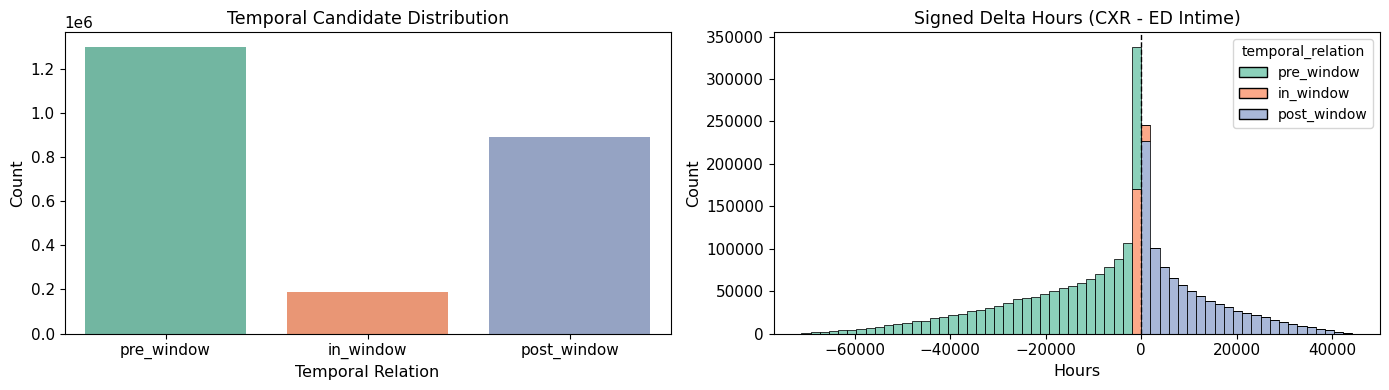

C:\Users\927997.ADIR\AppData\Local\Temp\ipykernel_13908\2531170341.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_links_long, x="strategy", y="n_links", palette="Set3")


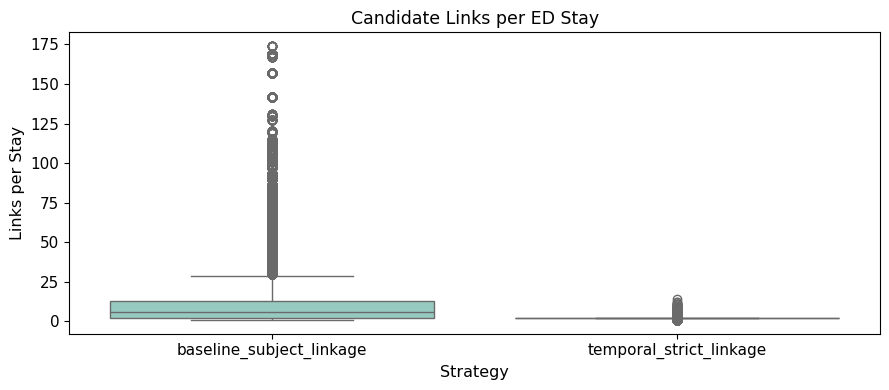

C:\Users\927997.ADIR\AppData\Local\Temp\ipykernel_13908\2531170341.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=window_counts, x="temporal_relation", y="count", palette="Set2")
C:\Users\927997.ADIR\AppData\Local\Temp\ipykernel_13908\2531170341.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_links_long, x="strategy", y="n_links", palette="Set3")


Diagnostics exported:
- C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\temporal_window_relation_counts.csv
- C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\candidate_link_multiplicity_summary.csv
- C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\temporal_window_relation_counts.png
- C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\temporal_signed_delta_distribution.png
- C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\candidate_link_multiplicity_boxplot.png


In [ ]:
# =====================================================================
# Step 2.2: Temporal alignment and linkage multiplicity visuals
# =====================================================================

print("Step 2.2: Temporal alignment and linkage multiplicity visuals...")

# ---------------------------------------------------------
# 0) Preconditions
# ---------------------------------------------------------
required_diag_objs = ["df_baseline_candidates", "df_temporal_candidates_raw", "df_temporal_candidates"]
missing_diag_objs = [x for x in required_diag_objs if x not in globals()]
if missing_diag_objs:
    raise RuntimeError(f"Missing required objects for diagnostics: {missing_diag_objs}")

# ---------------------------------------------------------
# 1) Temporal window distribution table
# ---------------------------------------------------------
window_counts = (
    df_temporal_candidates_raw["temporal_relation"]
    .value_counts()
    .reindex(["pre_window", "in_window", "post_window"], fill_value=0)
    .rename_axis("temporal_relation")
    .reset_index(name="count")
)

# ---------------------------------------------------------
# 2) Linkage multiplicity per strategy
# ---------------------------------------------------------
baseline_links_per_stay = (
    df_baseline_candidates[["subject_id", "stay_id"]]
    .dropna()
    .value_counts()
    .rename("n_links")
    .reset_index()
)

temporal_links_per_stay = (
    df_temporal_candidates[["subject_id", "stay_id"]]
    .dropna()
    .value_counts()
    .rename("n_links")
    .reset_index()
)

if baseline_links_per_stay.empty or temporal_links_per_stay.empty:
    raise RuntimeError("Multiplicity diagnostics require non-empty baseline and temporal candidate links.")

df_link_multiplicity_summary = pd.DataFrame([
    {
        "strategy": "baseline_subject_linkage",
        "stays": int(len(baseline_links_per_stay)),
        "mean_links": round(float(baseline_links_per_stay["n_links"].mean()), 4),
        "median_links": round(float(baseline_links_per_stay["n_links"].median()), 4),
        "p95_links": round(float(baseline_links_per_stay["n_links"].quantile(0.95)), 4),
        "max_links": int(baseline_links_per_stay["n_links"].max()),
    },
    {
        "strategy": "temporal_strict_linkage",
        "stays": int(len(temporal_links_per_stay)),
        "mean_links": round(float(temporal_links_per_stay["n_links"].mean()), 4),
        "median_links": round(float(temporal_links_per_stay["n_links"].median()), 4),
        "p95_links": round(float(temporal_links_per_stay["n_links"].quantile(0.95)), 4),
        "max_links": int(temporal_links_per_stay["n_links"].max()),
    },
])

display(window_counts)
display(df_link_multiplicity_summary)

# ---------------------------------------------------------
# 3) Inline diagnostic plots
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=window_counts, x="temporal_relation", y="count", palette="Set2", ax=axes[0])
axes[0].set_title("Temporal Candidate Distribution")
axes[0].set_xlabel("Temporal Relation")
axes[0].set_ylabel("Count")

sns.histplot(
    data=df_temporal_candidates_raw,
    x="signed_delta_hours",
    hue="temporal_relation",
    bins=60,
    multiple="stack",
    palette="Set2",
    ax=axes[1],
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Signed Delta Hours (CXR - ED Intime)")
axes[1].set_xlabel("Hours")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

df_links_long = pd.concat(
    [
        baseline_links_per_stay.assign(strategy="baseline_subject_linkage"),
        temporal_links_per_stay.assign(strategy="temporal_strict_linkage"),
    ],
    ignore_index=True,
)

plt.figure(figsize=(9, 4))
sns.boxplot(data=df_links_long, x="strategy", y="n_links", palette="Set3")
plt.title("Candidate Links per ED Stay")
plt.xlabel("Strategy")
plt.ylabel("Links per Stay")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4) Export diagnostic artifacts
# ---------------------------------------------------------
if "BASE_DIR" in globals():
    quality_dir = BASE_DIR / "quality_reports"
    quality_dir.mkdir(parents=True, exist_ok=True)

    window_counts_path = quality_dir / "temporal_window_relation_counts.csv"
    multiplicity_path = quality_dir / "candidate_link_multiplicity_summary.csv"
    delta_hist_path = quality_dir / "temporal_signed_delta_distribution.png"
    relation_bar_path = quality_dir / "temporal_window_relation_counts.png"
    link_boxplot_path = quality_dir / "candidate_link_multiplicity_boxplot.png"

    window_counts.to_csv(window_counts_path, index=False)
    df_link_multiplicity_summary.to_csv(multiplicity_path, index=False)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=window_counts, x="temporal_relation", y="count", palette="Set2")
    plt.title("Temporal Candidate Distribution")
    plt.xlabel("Temporal Relation")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(relation_bar_path, dpi=220, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(10, 4))
    sns.histplot(
        data=df_temporal_candidates_raw,
        x="signed_delta_hours",
        hue="temporal_relation",
        bins=60,
        multiple="stack",
        palette="Set2",
    )
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.title("Signed Delta Hours (CXR - ED Intime)")
    plt.xlabel("Hours")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(delta_hist_path, dpi=220, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(9, 4))
    sns.boxplot(data=df_links_long, x="strategy", y="n_links", palette="Set3")
    plt.title("Candidate Links per ED Stay")
    plt.xlabel("Strategy")
    plt.ylabel("Links per Stay")
    plt.tight_layout()
    plt.savefig(link_boxplot_path, dpi=220, bbox_inches="tight")
    plt.close()

    print("Diagnostics exported:")
    print(f"- {window_counts_path}")
    print(f"- {multiplicity_path}")
    print(f"- {relation_bar_path}")
    print(f"- {delta_hist_path}")
    print(f"- {link_boxplot_path}")


**Step 3: Hospital Outcome Attachment and Label Governance**

This step attaches hospital admission outcomes to both candidate cohorts. The admissions table is loaded from MIMIC-IV hospital data, deduplicated at the admission level, and merged with each cohort using `subject_id` and `hadm_id`.

**Main Operations**  
◽ Load `admissions.csv.gz` with admission time, discharge time, and hospital mortality flag  
◽ Deduplicate admissions using `subject_id` and `hadm_id`  
◽ Merge hospital outcomes onto both baseline and temporal-strict cohorts  
◽ Create explicit label-governance fields for observed and missing outcomes  
◽ Preserve missing outcome status instead of silently converting it into a negative label  
◽ Create statistics-ready binary mortality fields for descriptive analysis  

**Technical and Clinical Significance**  
Outcome labels must be handled carefully because not every ED encounter has a valid hospital admission outcome. This step separates observed mortality labels from missing or not-applicable outcomes, preventing incorrect supervised labels from entering later modeling stages.

**Expected Outcome**  
Both candidate cohorts receive governed mortality-label fields, including source outcome values, missing-outcome indicators, and analysis-ready mortality variables.

In [ ]:
# =====================================================================
# Step 3: Hospital Outcome Attachment and Label Governance
# =====================================================================

print("Executing Step 3: Hospital Outcome Attachment and Label Governance...")

# ---------------------------------------------------------
# 0) Preconditions
# ---------------------------------------------------------
required = ["BASE_DIR", "df_multimodal_baseline", "df_multimodal_temporal"]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}. Run befor Steps first.")

# ---------------------------------------------------------
# 1) Load admissions data
# ---------------------------------------------------------
PATH_HOSP = BASE_DIR / "mimic-iv" / "hosp"
adm_file = PATH_HOSP / "admissions.csv.gz"
if not adm_file.exists():
    raise FileNotFoundError(f"Admissions file not found: {adm_file}")

adm_cols = ["subject_id", "hadm_id", "admittime", "dischtime", "hospital_expire_flag"]
adm_dtypes = {
    "subject_id": "Int64",
    "hadm_id": "Int64",
    "hospital_expire_flag": "Int64",
}

df_admissions = pd.read_csv(
    adm_file,
    compression="gzip",
    usecols=adm_cols,
    dtype=adm_dtypes,
    parse_dates=["admittime", "dischtime"],
).drop_duplicates(subset=["subject_id", "hadm_id"], keep="first")

print(f"Admissions rows loaded: {len(df_admissions):,}")

# ---------------------------------------------------------
# 2) Outcome attachment utility
# ---------------------------------------------------------
def attach_outcomes(df_in: pd.DataFrame, strategy_name: str) -> pd.DataFrame:
    df = df_in.copy()
    required_keys = ["subject_id", "hadm_id", "stay_id"]
    missing_keys = [k for k in required_keys if k not in df.columns]
    if missing_keys:
        raise KeyError(f"{strategy_name}: missing required keys {missing_keys}")

    df = pd.merge(
        df,
        df_admissions,
        on=["subject_id", "hadm_id"],
        how="left",
        suffixes=("", "_adm"),
    )

    # Keep exactly one row per ED stay to preserve cohort identity.
    df = df.drop_duplicates(subset=["subject_id", "stay_id"], keep="first")

    # Label governance fields.
    df["label_outcome_missing"] = df["hospital_expire_flag"].isna().astype("int8")
    df["label_mortality_observed"] = df["hospital_expire_flag"].astype("Float64")
    df["label_mortality_binary_for_stats"] = df["hospital_expire_flag"].fillna(0).astype("int8")
    df["cohort_strategy"] = strategy_name

    return df

# ---------------------------------------------------------
# 3) Apply to both strategies
# ---------------------------------------------------------
df_final_baseline = attach_outcomes(df_multimodal_baseline, "baseline_subject_linkage")
df_final_temporal = attach_outcomes(df_multimodal_temporal, "temporal_strict_linkage")

print(f"Outcome integration complete: {len(df_final_baseline):,} baseline, {len(df_final_temporal):,} temporal.")


Executing: Attaching admissions outcomes...
Admissions rows loaded: 546,028
Outcome integration complete: 212,272 baseline, 89,747 temporal.


**Step 4: Strategy-Level Cohort Quality Summary**

This step computes standardized quality metrics for the baseline and temporal-strict cohorts. The same metric function is applied to both strategies so that coverage, outcome completeness, mortality rate, duplicate burden, and candidate linkage multiplicity can be compared fairly.

**Main Operations**  
◽ Define a unified quality-metric function for cohort comparison  
◽ Calculate total rows, unique patients, unique stays, and observed-label rows  
◽ Measure ED stay coverage for each strategy  
◽ Calculate missing outcome rate and observed mortality rate  
◽ Audit duplicate ED stays in the final linked cohorts  
◽ Summarize candidate linkage multiplicity using mean, median, and upper-percentile statistics  
◽ Export quality-comparison tables for downstream selection  

**Technical and Clinical Significance**  
Using one shared metric function prevents inconsistent comparison between cohort strategies. This is important because a larger cohort is not always better if it has weaker temporal validity, higher missingness, or duplicate encounter linkage.

**Expected Outcome**  
A strategy-level quality comparison table is created, providing the evidence needed to select the final cohort construction strategy.

In [ ]:
# =====================================================================
# Step 4: Strategy-Level Cohort Quality Summary
# =====================================================================

print("Step 4: Strategy-Level Cohort Quality Summary...")

# ---------------------------------------------------------
# 0) Preconditions
# ---------------------------------------------------------
required_objs = [
    "df_ed_timeline",
    "df_baseline_candidates",
    "df_temporal_candidates",
    "df_final_baseline",
    "df_final_temporal",
]
missing = [x for x in required_objs if x not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects for this Step: {missing}")

total_ed_stays = int(df_ed_timeline["stay_id"].nunique())

# ---------------------------------------------------------
# 1) Unified quality metrics utility (single source of truth)
# ---------------------------------------------------------
def quality_metrics(
    final_df: pd.DataFrame,
    candidates_df: pd.DataFrame,
    strategy_name: str,
    total_ed_stays: int,
) -> dict:
    rows_total = int(len(final_df))
    unique_patients = int(final_df["subject_id"].nunique()) if "subject_id" in final_df.columns else 0
    unique_stays = int(final_df["stay_id"].nunique()) if "stay_id" in final_df.columns else 0
    coverage_pct = (unique_stays / max(total_ed_stays, 1)) * 100.0

    if "label_outcome_missing" in final_df.columns:
        missing_outcomes_count = int(final_df["label_outcome_missing"].sum())
        rows_observed = int((final_df["label_outcome_missing"] == 0).sum())
    elif "hospital_expire_flag" in final_df.columns:
        missing_outcomes_count = int(final_df["hospital_expire_flag"].isna().sum())
        rows_observed = int(final_df["hospital_expire_flag"].notna().sum())
    else:
        missing_outcomes_count = 0
        rows_observed = rows_total
    missing_outcomes_pct = (missing_outcomes_count / max(rows_total, 1)) * 100.0

    if "label_mortality_observed" in final_df.columns:
        n_expired = int((final_df["label_mortality_observed"] == 1).sum())
        n_survived = int((final_df["label_mortality_observed"] == 0).sum())
    elif "hospital_expire_flag" in final_df.columns:
        observed = final_df["hospital_expire_flag"].dropna()
        n_expired = int((observed == 1).sum())
        n_survived = int((observed == 0).sum())
    else:
        n_expired = 0
        n_survived = 0
    observed_den = max(n_expired + n_survived, 1)
    mortality_rate_observed_pct = (n_expired / observed_den) * 100.0

    duplicate_rows_on_stay = int(final_df.duplicated(subset=["subject_id", "stay_id"]).sum())
    duplication_rate_final_pct = (duplicate_rows_on_stay / max(rows_total, 1)) * 100.0

    mean_candidate_links = 0.0
    median_candidate_links = 0.0
    p95_candidate_links = 0.0
    if (
        isinstance(candidates_df, pd.DataFrame)
        and {"subject_id", "stay_id"}.issubset(candidates_df.columns)
        and len(candidates_df) > 0
    ):
        cand_pairs = candidates_df[["subject_id", "stay_id"]].dropna()
        if len(cand_pairs) > 0:
            links_per_stay = cand_pairs.value_counts().rename("n_links").reset_index()
            mean_candidate_links = float(links_per_stay["n_links"].mean())
            median_candidate_links = float(links_per_stay["n_links"].median())
            p95_candidate_links = float(links_per_stay["n_links"].quantile(0.95))

    return {
        "strategy": strategy_name,
        "rows_total": rows_total,
        "rows_observed": rows_observed,
        "patients_unique": unique_patients,
        "stays_unique": unique_stays,
        "coverage_pct": round(coverage_pct, 4),
        "missing_outcomes_count": missing_outcomes_count,
        "missing_outcomes_pct": round(missing_outcomes_pct, 4),
        "expired_observed": n_expired,
        "survived_observed": n_survived,
        "mortality_rate_observed_pct": round(mortality_rate_observed_pct, 4),
        "duplicate_rows_on_stay": duplicate_rows_on_stay,
        "duplication_rate_final_pct": round(duplication_rate_final_pct, 6),
        "mean_candidate_links_per_stay": round(mean_candidate_links, 4),
        "median_candidate_links_per_stay": round(median_candidate_links, 4),
        "p95_candidate_links_per_stay": round(p95_candidate_links, 4),
    }

# ---------------------------------------------------------
# 2) Calculate and export comparison
# ---------------------------------------------------------
comparison_rows = [
    quality_metrics(
        df_final_baseline,
        df_baseline_candidates,
        "baseline_subject_linkage",
        total_ed_stays=total_ed_stays,
    ),
    quality_metrics(
        df_final_temporal,
        df_temporal_candidates,
        "temporal_strict_linkage",
        total_ed_stays=total_ed_stays,
    ),
]

summary_cols = [
    "strategy",
    "rows_total",
    "rows_observed",
    "patients_unique",
    "stays_unique",
    "coverage_pct",
    "missing_outcomes_count",
    "missing_outcomes_pct",
    "expired_observed",
    "survived_observed",
    "mortality_rate_observed_pct",
    "duplicate_rows_on_stay",
    "mean_candidate_links_per_stay",
    "median_candidate_links_per_stay",
    "p95_candidate_links_per_stay",
]

df_strategy_outcome_summary = (
    pd.DataFrame(comparison_rows)
    .sort_values("strategy")
    .reset_index(drop=True)[summary_cols]
)

if "BASE_DIR" in globals():
    quality_dir = BASE_DIR / "quality_reports"
    quality_dir.mkdir(parents=True, exist_ok=True)
    strategy_summary_path = quality_dir / "cohort_strategy_outcome_summary.csv"
    df_strategy_outcome_summary.to_csv(strategy_summary_path, index=False)
    print(f"Quality comparison report saved: {strategy_summary_path}")

display(df_strategy_outcome_summary)


Generating cohort quality comparison...
Quality comparison report saved: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cohort_strategy_outcome_summary.csv


,strategy,rows_total,rows_observed,patients_unique,stays_unique,coverage_pct,missing_outcomes_count,missing_outcomes_pct,expired_observed,survived_observed,mortality_rate_observed_pct,duplicate_rows_on_stay,mean_candidate_links_per_stay,median_candidate_links_per_stay,p95_candidate_links_per_stay
0,baseline_subject_linkage,212272,122706,61856,212272,49.9361,89566,42.1940,3170,119536,2.5834,0,11.2075,6.0,41.0
1,temporal_strict_linkage,89747,64229,52766,89747,21.1126,25518,28.4333,2322,61907,3.6152,0,2.0989,2.0,3.0


**Step 5: Outcome Diagnostics, Observed Subsets, and Candidate Cohort Export**

This step creates observed-label subsets for both candidate cohorts and exports the intermediate cohort artifacts. It also summarizes outcome availability, mortality distribution, and cohort structure before the final strategy-selection step.

**Main Operations**  
◽ Create observed-only supervised subsets for baseline and temporal-strict cohorts  
◽ Summarize total rows, unique patients, unique ED stays, and admission-linked records  
◽ Report missing outcome rates and observed mortality rates  
◽ Export full and observed-only versions of both candidate cohorts  
◽ Save cohort comparison outputs for reproducibility  
◽ Preview governed label fields for manual inspection  

**Technical and Clinical Significance**  
Observed-only subsets are needed for supervised mortality prediction, while full cohorts remain useful for descriptive and downstream multimodal linkage work. Exporting both versions preserves flexibility without mixing observed and missing-label records.

**Expected Outcome**  
Full and observed-only candidate cohorts are saved, and outcome diagnostics are available for final strategy selection.

In [ ]:
# =====================================================================
# Step 5: Outcome Diagnostics, Observed Subsets, and Candidate Cohort Export
# =====================================================================

print("Step 5: Outcome Diagnostics, Observed Subsets, and Candidate Cohort Export...")

# ---------------------------------------------------------
# 0) Preconditions
# ---------------------------------------------------------
required = ["df_final_baseline", "df_final_temporal", "BASE_DIR"]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}. Run befor Steps first.")

# ---------------------------------------------------------
# 1) Create observed-only subsets for strict supervised training
# ---------------------------------------------------------
df_final_baseline_observed = df_final_baseline[df_final_baseline["label_outcome_missing"] == 0].copy()
df_final_temporal_observed = df_final_temporal[df_final_temporal["label_outcome_missing"] == 0].copy()

# ---------------------------------------------------------
# 2) Detailed cohort diagnostics
# ---------------------------------------------------------
def cohort_summary(df: pd.DataFrame, name: str) -> dict:
    n_total = len(df)
    n_patients = df["subject_id"].nunique()
    n_stays = df["stay_id"].nunique()
    n_hadm = int(df["hadm_id"].notna().sum())
    n_missing = int(df["label_outcome_missing"].sum())
    n_expired = int((df["label_mortality_observed"] == 1).sum())
    n_survived = int((df["label_mortality_observed"] == 0).sum())
    observed_den = max(n_expired + n_survived, 1)
    mort_rate_observed = (n_expired / observed_den) * 100.0
    return {
        "cohort": name,
        "rows_total": n_total,
        "patients_unique": n_patients,
        "stays_unique": n_stays,
        "rows_with_hadm_id": n_hadm,
        "outcome_missing": n_missing,
        "expired_observed": n_expired,
        "survived_observed": n_survived,
        "mortality_rate_observed_pct": round(mort_rate_observed, 4),
    }

df_cohort_comparison = pd.DataFrame([
    cohort_summary(df_final_baseline, "baseline_subject_linkage"),
    cohort_summary(df_final_temporal, "temporal_strict_linkage"),
])

# ---------------------------------------------------------
# 3) Export cohorts and comparison
# ---------------------------------------------------------
quality_dir = BASE_DIR / "quality_reports"
quality_dir.mkdir(parents=True, exist_ok=True)

baseline_full_path = BASE_DIR / "cohort_baseline_subject_linkage_full.csv"
baseline_obs_path = BASE_DIR / "cohort_baseline_subject_linkage_observed.csv"
temporal_full_path = BASE_DIR / "cohort_temporal_strict_full.csv"
temporal_obs_path = BASE_DIR / "cohort_temporal_strict_observed.csv"
comparison_path = quality_dir / "cohort_strategy_comparison.csv"

df_final_baseline.to_csv(baseline_full_path, index=False)
df_final_baseline_observed.to_csv(baseline_obs_path, index=False)
df_final_temporal.to_csv(temporal_full_path, index=False)
df_final_temporal_observed.to_csv(temporal_obs_path, index=False)
df_cohort_comparison.to_csv(comparison_path, index=False)

# ---------------------------------------------------------
# 4) Console reporting
# ---------------------------------------------------------
print("\nExports completed.")
print(f"- Baseline full rows: {len(df_final_baseline):,}")
print(f"- Baseline observed rows: {len(df_final_baseline_observed):,}")
print(f"- Temporal full rows: {len(df_final_temporal):,}")
print(f"- Temporal observed rows: {len(df_final_temporal_observed):,}")

print("\nStrategy comparison:")
display(df_cohort_comparison)

# ---------------------------------------------------------
# 5) Label preview
# ---------------------------------------------------------
preview_cols = [
    "subject_id", "stay_id", "hadm_id",
    "intime", "outtime", "cxr_datetime",
    "hospital_expire_flag",
    "label_outcome_missing",
    "label_mortality_observed",
    "label_mortality_binary_for_stats",
]
preview_cols = [c for c in preview_cols if c in df_final_baseline.columns]

print("\nPreview baseline:")
display(df_final_baseline[preview_cols].head(3))
print("\nPreview temporal-strict:")
display(df_final_temporal[preview_cols].head(3))


Outcome diagnostics and cohort export...

Exports completed.
- Baseline full rows: 212,272
- Baseline observed rows: 122,706
- Temporal full rows: 89,747
- Temporal observed rows: 64,229

Strategy comparison:


,cohort,rows_total,patients_unique,stays_unique,rows_with_hadm_id,outcome_missing,expired_observed,survived_observed,mortality_rate_observed_pct
0,baseline_subject_linkage,212272,61856,212272,122717,89566,3170,119536,2.5834
1,temporal_strict_linkage,89747,52766,89747,64233,25518,2322,61907,3.6152



Preview baseline:


,subject_id,stay_id,hadm_id,intime,outtime,cxr_datetime,hospital_expire_flag,label_outcome_missing,label_mortality_observed,label_mortality_binary_for_stats
0,10000032,32952584,29079034,2180-07-22 16:24:00,2180-07-23 05:54:00,2180-05-06 21:30:14,0,0,0.0,0
1,10000032,33258284,22595853,2180-05-06 19:17:00,2180-05-06 23:30:00,2180-05-06 21:30:14,0,0,0.0,0
2,10000032,35968195,25742920,2180-08-05 20:58:00,2180-08-06 01:44:00,2180-05-06 21:30:14,0,0,0.0,0



Preview temporal-strict:


,subject_id,stay_id,hadm_id,intime,outtime,cxr_datetime,hospital_expire_flag,label_outcome_missing,label_mortality_observed,label_mortality_binary_for_stats
0,10000032,32952584,29079034,2180-07-22 16:24:00,2180-07-23 05:54:00,2180-07-23 08:05:56,0,0,0.0,0
1,10000032,33258284,22595853,2180-05-06 19:17:00,2180-05-06 23:30:00,2180-05-06 21:30:14,0,0,0.0,0
2,10000032,35968195,25742920,2180-08-05 20:58:00,2180-08-06 01:44:00,2180-08-05 23:44:24,0,0,0.0,0


**Step 6: Final Cohort Quality Comparison Table**

This step regenerates the cohort quality comparison table using the unified metric function. It ensures that the latest baseline and temporal-strict cohorts are compared with the same definitions before automated strategy selection.

**Main Operations**  
◽ Recalculate quality metrics for both candidate cohorts  
◽ Use the same total ED stay denominator for coverage comparison  
◽ Compare row counts, observed-label rows, patient counts, and stay counts  
◽ Compare missing outcome rates, mortality rates, duplicate rates, and linkage multiplicity  
◽ Export machine-readable and readable versions of the comparison table  

**Technical and Clinical Significance**  
This step provides the final standardized comparison layer before selecting the project cohort. Recomputing the table immediately before selection reduces the risk of using stale intermediate metrics.

**Expected Outcome**  
A refreshed `df_quality_comparison` table is available and exported for final cohort selection and reporting.

In [ ]:
# =====================================================================
# Step 6: Final Cohort Quality Comparison Table
# =====================================================================

print("Step 6: Final Cohort Quality Comparison Table...")

# ---------------------------------------------------------
# 0) Preconditions
# ---------------------------------------------------------
required_objs = [
    "df_ed_timeline",
    "df_baseline_candidates",
    "df_temporal_candidates",
    "df_final_baseline",
    "df_final_temporal",
    "BASE_DIR",
]
missing = [x for x in required_objs if x not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects for comparison: {missing}")

if "quality_metrics" not in globals():
    raise RuntimeError("quality_metrics is not defined. Run befor Steps first.")

total_ed_stays = int(df_ed_timeline["stay_id"].nunique())

# ---------------------------------------------------------
# 1) Calculate and export comparison using unified utility
# ---------------------------------------------------------
comparison_rows = [
    quality_metrics(
        df_final_baseline,
        df_baseline_candidates,
        "baseline_subject_linkage",
        total_ed_stays=total_ed_stays,
    ),
    quality_metrics(
        df_final_temporal,
        df_temporal_candidates,
        "temporal_strict_linkage",
        total_ed_stays=total_ed_stays,
    ),
]

df_quality_comparison = pd.DataFrame(comparison_rows).sort_values("strategy").reset_index(drop=True)

df_quality_comparison["duplication_rate_final_pct_str"] = (
    df_quality_comparison["duplication_rate_final_pct"].map(lambda x: f"{x:.4f}%")
)

quality_dir = BASE_DIR / "quality_reports"
quality_dir.mkdir(parents=True, exist_ok=True)

quality_table_path = quality_dir / "cohort_quality_comparison.csv"
quality_table_readable_path = quality_dir / "cohort_quality_comparison_readable.csv"

df_quality_comparison.to_csv(quality_table_path, index=False)
df_quality_comparison.to_csv(quality_table_readable_path, index=False)

print("Cohort quality comparison table created.")
print(f"Saved to: {quality_table_path}")
display(df_quality_comparison)


Cohort quality comparison...
Cohort quality comparison table created.
Saved to: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cohort_quality_comparison.csv


,strategy,rows_total,rows_observed,patients_unique,stays_unique,coverage_pct,missing_outcomes_count,missing_outcomes_pct,expired_observed,survived_observed,mortality_rate_observed_pct,duplicate_rows_on_stay,duplication_rate_final_pct,mean_candidate_links_per_stay,median_candidate_links_per_stay,p95_candidate_links_per_stay,duplication_rate_final_pct_str
0,baseline_subject_linkage,212272,122706,61856,212272,49.9361,89566,42.1940,3170,119536,2.5834,0,0.0,11.2075,6.0,41.0,0.0000%
1,temporal_strict_linkage,89747,64229,52766,89747,21.1126,25518,28.4333,2322,61907,3.6152,0,0.0,2.0989,2.0,3.0,0.0000%


**Step 7: Final Cohort Strategy Selection and Gate-0 Reproducibility Guard**

This step automatically selects the final cohort strategy using a configurable policy and then applies a Gate-0 reproducibility guard. The default selection mode prioritizes temporal validity, while the guard checks whether the selected cohort remains consistent with the stored reference snapshot.

**Main Operations**  
◽ Apply the configured cohort-selection policy, such as `validity_first` or `size_first`  
◽ Select the preferred cohort from the baseline and temporal-strict candidates  
◽ Compare current row counts, observed-label counts, missing outcome rate, and mortality rate against the reference snapshot  
◽ Check for duplicate ED stays in the selected cohort  
◽ Create a reference snapshot on the first validated run when needed  
◽ Export the selected final cohort and observed-only selected subset  
◽ Save the Gate-0 audit report and cohort-selection summary  

**Technical and Clinical Significance**  
Gate-0 acts as a reproducibility checkpoint before downstream notebooks depend on the cohort. It helps detect unexpected cohort drift caused by data changes, code edits, path differences, or merge behavior changes.

**Expected Outcome**  
The final selected cohort is saved, the observed-label supervised subset is exported, and a Gate-0 audit report documents whether the current run is consistent with the expected cohort baseline.

In [ ]:
# =====================================================================
# Step 7: Final Cohort Strategy Selection and Gate-0 Reproducibility Guard
# =====================================================================

print("Step 7: Final Cohort Strategy Selection and Gate-0 Reproducibility Guard...")

# ---------------------------------------------------------
# 0) Preconditions
# ---------------------------------------------------------
required = ["df_final_baseline", "df_final_temporal", "df_quality_comparison", "BASE_DIR"]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}. Run the previous cells first.")

# ---------------------------------------------------------
# 1) User-configurable selection policy
# ---------------------------------------------------------
selection_mode = "validity_first"

# ---------------------------------------------------------
# 2) Build strategy summary from unified quality table
# ---------------------------------------------------------
required_summary_cols = [
    "strategy",
    "rows_total",
    "rows_observed",
    "patients_unique",
    "stays_unique",
    "missing_outcomes_count",
    "missing_outcomes_pct",
    "expired_observed",
    "survived_observed",
    "mortality_rate_observed_pct",
    "duplicate_rows_on_stay",
]
missing_summary_cols = [c for c in required_summary_cols if c not in df_quality_comparison.columns]
if missing_summary_cols:
    raise KeyError(
        "df_quality_comparison is missing required selection columns: "
        f"{missing_summary_cols}. Re-run befor Steps."
    )

def _to_native(record: dict) -> dict:
    normalized = {}
    for key, value in record.items():
        if isinstance(value, np.integer):
            normalized[key] = int(value)
        elif isinstance(value, np.floating):
            normalized[key] = float(value)
        else:
            normalized[key] = value
    return normalized

strategy_lookup = {
    row["strategy"]: _to_native(row)
    for row in df_quality_comparison.to_dict(orient="records")
}

for required_strategy in ["baseline_subject_linkage", "temporal_strict_linkage"]:
    if required_strategy not in strategy_lookup:
        raise KeyError(
            f"Strategy '{required_strategy}' is missing from df_quality_comparison. "
            "Re-run befor Step to rebuild the comparison table."
        )

summary_baseline = strategy_lookup["baseline_subject_linkage"]
summary_temporal = strategy_lookup["temporal_strict_linkage"]

# ---------------------------------------------------------
# 3) Selection logic
# ---------------------------------------------------------
if selection_mode == "validity_first":
    selected_name = "temporal_strict_linkage"
    selected_df = df_final_temporal.copy()
    selected_summary = summary_temporal
elif selection_mode == "size_first":
    if summary_baseline["rows_total"] >= summary_temporal["rows_total"]:
        selected_name = "baseline_subject_linkage"
        selected_df = df_final_baseline.copy()
        selected_summary = summary_baseline
    else:
        selected_name = "temporal_strict_linkage"
        selected_df = df_final_temporal.copy()
        selected_summary = summary_temporal
else:
    raise ValueError("selection_mode must be either 'validity_first' or 'size_first'.")

selected_observed_df = selected_df[selected_df["label_outcome_missing"] == 0].copy()
if len(selected_observed_df) == 0:
    raise RuntimeError("Selected observed-only cohort is empty. Stop and inspect outcome linkage.")

# ---------------------------------------------------------
# 4) Gate-0 reproducibility guard
# ---------------------------------------------------------
comparison_table = (
    pd.DataFrame([summary_baseline, summary_temporal])
    .sort_values("strategy")
    .reset_index(drop=True)
)

quality_dir = BASE_DIR / "quality_reports"
quality_dir.mkdir(parents=True, exist_ok=True)

snapshot_cols = [
    "strategy",
    "rows_total",
    "rows_observed",
    "stays_unique",
    "missing_outcomes_pct",
    "mortality_rate_observed_pct",
    "duplicate_rows_on_stay",
]

snapshot_current_path = quality_dir / "cohort_gate0_snapshot_current.csv"
snapshot_reference_path = quality_dir / "cohort_gate0_snapshot_reference.csv"
guard_report_path = quality_dir / "cohort_gate0_guard_report.json"

comparison_table[snapshot_cols].to_csv(snapshot_current_path, index=False)

thresholds = {
    "row_drop_warn_pct": 5.0,
    "row_drop_alert_pct": 15.0,
    "missing_outcome_shift_warn_pct": 2.0,
    "mortality_shift_alert_pct": 5.0,
    "duplicate_rows_allowed": 0,
}

# Hard duplicate check in current run
if (comparison_table["duplicate_rows_on_stay"] > thresholds["duplicate_rows_allowed"]).any():
    bad = comparison_table.loc[
        comparison_table["duplicate_rows_on_stay"] > thresholds["duplicate_rows_allowed"],
        ["strategy", "duplicate_rows_on_stay"],
    ]
    raise RuntimeError(f"Duplicate stay rows detected in final cohorts: {bad.to_dict(orient='records')}")

def pct_drop(reference_value: float, current_value: float) -> float:
    return max(((reference_value - current_value) / max(reference_value, 1.0)) * 100.0, 0.0)

warnings_list = []
alerts_list = []

if snapshot_reference_path.exists():
    reference_df = pd.read_csv(snapshot_reference_path)
    merged = pd.merge(
        comparison_table[snapshot_cols],
        reference_df[snapshot_cols],
        on="strategy",
        suffixes=("_current", "_reference"),
        how="inner",
    )

    selected_row = merged[merged["strategy"] == selected_name]
    if selected_row.empty:
        alerts_list.append("Selected strategy not found in reference snapshot merge.")
    else:
        row = selected_row.iloc[0]

        rows_drop_pct = pct_drop(row["rows_total_reference"], row["rows_total_current"])
        stays_drop_pct = pct_drop(row["stays_unique_reference"], row["stays_unique_current"])
        missing_shift_pct = abs(row["missing_outcomes_pct_current"] - row["missing_outcomes_pct_reference"])
        mortality_shift_pct = abs(
            row["mortality_rate_observed_pct_current"] - row["mortality_rate_observed_pct_reference"]
        )

        if rows_drop_pct > thresholds["row_drop_alert_pct"]:
            alerts_list.append(f"Row drop alert: {rows_drop_pct:.3f}% > {thresholds['row_drop_alert_pct']}%")
        elif rows_drop_pct > thresholds["row_drop_warn_pct"]:
            warnings_list.append(f"Row drop warning: {rows_drop_pct:.3f}% > {thresholds['row_drop_warn_pct']}%")

        if stays_drop_pct > thresholds["row_drop_alert_pct"]:
            alerts_list.append(f"Unique stay drop alert: {stays_drop_pct:.3f}% > {thresholds['row_drop_alert_pct']}%")
        elif stays_drop_pct > thresholds["row_drop_warn_pct"]:
            warnings_list.append(f"Unique stay drop warning: {stays_drop_pct:.3f}% > {thresholds['row_drop_warn_pct']}%")

        if missing_shift_pct > thresholds["missing_outcome_shift_warn_pct"]:
            warnings_list.append(
                f"Missing outcome shift warning: {missing_shift_pct:.3f}% > "
                f"{thresholds['missing_outcome_shift_warn_pct']}%"
            )

        if mortality_shift_pct > thresholds["mortality_shift_alert_pct"]:
            alerts_list.append(
                f"Mortality shift alert: {mortality_shift_pct:.3f}% > "
                f"{thresholds['mortality_shift_alert_pct']}%"
            )

    guard_status = "fail" if alerts_list else ("warn" if warnings_list else "pass")
else:
    # First validated run creates the baseline reference
    comparison_table[snapshot_cols].to_csv(snapshot_reference_path, index=False)
    guard_status = "baseline-created"
    warnings_list.append("Reference snapshot was not found; baseline reference created from current run.")

guard_report = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "selection_mode": selection_mode,
    "selected_strategy": selected_name,
    "guard_status": guard_status,
    "thresholds": thresholds,
    "warnings_list": warnings_list,
    "alerts_list": alerts_list,
}

with open(guard_report_path, "w", encoding="utf-8") as f:
    json.dump(guard_report, f, indent=2)

if alerts_list:
    raise RuntimeError(
        "Gate-0 alert triggered. Review quality_reports/cohort_gate0_guard_report.json before proceeding."
    )

# ---------------------------------------------------------
# 5) Save outputs
# ---------------------------------------------------------
final_full_path = BASE_DIR / "cohort_final_selected.csv"
final_observed_path = BASE_DIR / "cohort_final_selected_observed.csv"
selection_meta_path = quality_dir / "cohort_final_selection_metadata.json"
selection_table_path = quality_dir / "cohort_final_selection_comparison.csv"

selected_df.to_csv(final_full_path, index=False)
selected_observed_df.to_csv(final_observed_path, index=False)
comparison_table.to_csv(selection_table_path, index=False)

metadata = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "selection_mode": selection_mode,
    "selected_strategy": selected_name,
    "selected_summary": selected_summary,
    "all_strategies": [summary_baseline, summary_temporal],
    "gate0_guard_status": guard_status,
    "gate0_guard_report": str(guard_report_path),
    "output_files": {
        "final_full_csv": str(final_full_path),
        "final_observed_csv": str(final_observed_path),
        "comparison_csv": str(selection_table_path),
        "snapshot_current_csv": str(snapshot_current_path),
        "snapshot_reference_csv": str(snapshot_reference_path),
    },
}

with open(selection_meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

# ---------------------------------------------------------
# 6) Report
# ---------------------------------------------------------
print("Final cohort selection complete.")
print(f"  Selection mode: {selection_mode}")
print(f"  Selected strategy: {selected_name}")
print(f"  Guard status: {guard_status}")
print(f"  Final full rows: {len(selected_df):,}")
print(f"  Final observed rows: {len(selected_observed_df):,}")
print(f"  Final cohort file: {final_full_path}")
print(f"  Observed-only file: {final_observed_path}")
print(f"  Metadata file: {selection_meta_path}")
print(f"  Guard report: {guard_report_path}")

if warnings_list:
    print("\nWarnings:")
    for w in warnings_list:
        print(f"  {w}")

print("\nStrategy comparison:")
display(comparison_table)
display(selected_df.head(5))


Auto-selecting final cohort with Gate-0 guard...
Final cohort selection complete.
  Selection mode: validity_first
  Selected strategy: temporal_strict_linkage
  Guard status: pass
  Final full rows: 89,747
  Final observed rows: 64,229
  Final cohort file: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\cohort_final_selected.csv
  Observed-only file: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\cohort_final_selected_observed.csv
  Metadata file: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cohort_final_selection_metadata.json
  Guard report: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cohort_gate0_guard_report.json

Strategy comparison:


,strategy,rows_total,rows_observed,patients_unique,stays_unique,coverage_pct,missing_outcomes_count,missing_outcomes_pct,expired_observed,survived_observed,mortality_rate_observed_pct,duplicate_rows_on_stay,duplication_rate_final_pct,mean_candidate_links_per_stay,median_candidate_links_per_stay,p95_candidate_links_per_stay,duplication_rate_final_pct_str
0,baseline_subject_linkage,212272,122706,61856,212272,49.9361,89566,42.1940,3170,119536,2.5834,0,0.0,11.2075,6.0,41.0,0.0000%
1,temporal_strict_linkage,89747,64229,52766,89747,21.1126,25518,28.4333,2322,61907,3.6152,0,0.0,2.0989,2.0,3.0,0.0000%


,subject_id,stay_id,temperature,heartrate,resprate,o2sat,sbp,dbp,chiefcomplaint,hadm_id,...,signed_delta_hours,time_delta_minutes,temporal_relation,admittime,dischtime,hospital_expire_flag,label_outcome_missing,label_mortality_observed,label_mortality_binary_for_stats,cohort_strategy
0,10000032,32952584,97.800003,87.0,14.0,97.0,71.0,43.0,Hypotension,29079034,...,15.698889,941.933333,in_window,2180-07-23 12:35:00,2180-07-25 17:55:00,0,0,0.0,0,temporal_strict_linkage
1,10000032,33258284,98.400002,70.0,16.0,97.0,106.0,63.0,"Abd pain, Abdominal distention",22595853,...,2.220556,133.233333,in_window,2180-05-06 22:23:00,2180-05-07 17:15:00,0,0,0.0,0,temporal_strict_linkage
2,10000032,35968195,99.400002,105.0,18.0,96.0,106.0,57.0,"n/v/d, Abd pain",25742920,...,2.773333,166.400000,in_window,2180-08-05 23:44:00,2180-08-07 17:50:00,0,0,0.0,0,temporal_strict_linkage
3,10000032,38112554,98.900002,88.0,18.0,97.0,116.0,88.0,Abdominal distention,22841357,...,1.016667,61.000000,in_window,2180-06-26 18:27:00,2180-06-27 18:49:00,0,0,0.0,0,temporal_strict_linkage
4,10000032,39399961,98.699997,77.0,16.0,98.0,96.0,50.0,"Abdominal distention, Abd pain, LETHAGIC",29079034,...,2.198889,131.933333,in_window,2180-07-23 12:35:00,2180-07-25 17:55:00,0,0,0.0,0,temporal_strict_linkage


**Step 8: Cohort Quality Heatmaps and Direction-Aware Scoring**

This step visualizes key quality metrics for the candidate cohort strategies. It creates one heatmap for raw metric values and another score-based heatmap where metrics are scaled according to whether higher or lower values are preferred.

**Main Operations**  
◽ Prepare selected cohort-quality metrics for visualization  
◽ Generate a raw heatmap for coverage, mortality rate, missing outcome rate, and duplication rate  
◽ Scale quality metrics into direction-aware scores  
◽ Treat higher coverage as beneficial and lower missingness or duplication as beneficial  
◽ Keep observed mortality rate as descriptive rather than a selection-score component  
◽ Export score tables and heatmap figures  

**Technical and Clinical Significance**  
Visual comparison makes cohort trade-offs easier to inspect. Direction-aware scoring helps distinguish descriptive metrics from quality metrics and avoids treating all numeric values as automatically better when larger.

**Expected Outcome**  
Raw and score-based cohort quality heatmaps are saved, along with a score table for reporting and review.

Generating cohort quality heatmaps...


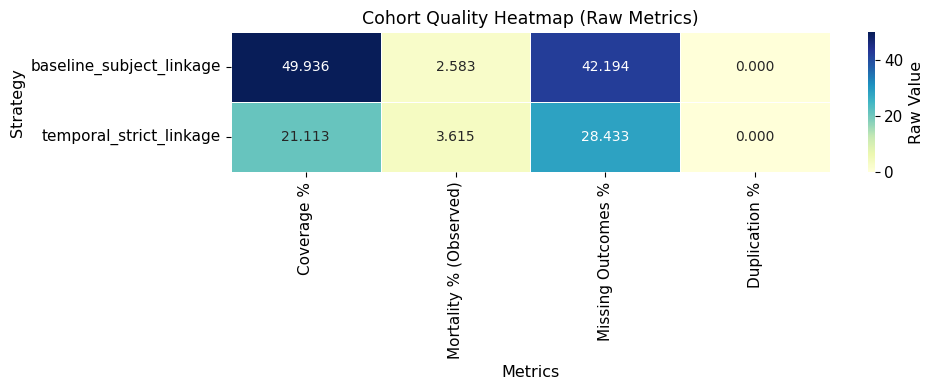

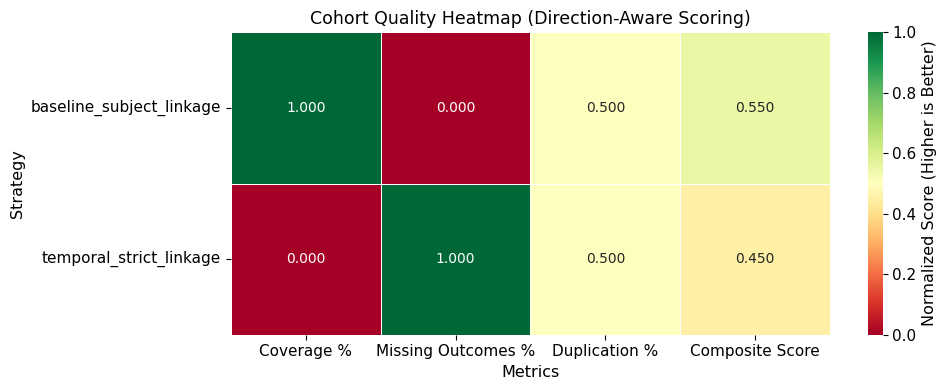

Heatmaps generated successfully.
Raw heatmap saved to: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cohort_quality_heatmap_raw.png
Score heatmap saved to: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cohort_quality_heatmap_score.png
Score table saved to: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cohort_quality_heatmap_scores.csv


In [ ]:
# =====================================================================
# Step 8: Cohort Quality Heatmaps and Direction-Aware Scoring
# =====================================================================

print("Step 8: Cohort Quality Heatmaps and Direction-Aware Scoring...")

# ---------------------------------------------------------
# 0) Preconditions
# ---------------------------------------------------------
if "df_quality_comparison" not in globals():
    raise RuntimeError("df_quality_comparison is not available. Run the cohort quality comparison cell first.")
if "BASE_DIR" not in globals():
    raise RuntimeError("BASE_DIR is not defined.")

required_cols = [
    "strategy",
    "coverage_pct",
    "mortality_rate_observed_pct",
    "missing_outcomes_pct",
    "duplication_rate_final_pct",
]
missing_cols = [c for c in required_cols if c not in df_quality_comparison.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in df_quality_comparison: {missing_cols}")

# ---------------------------------------------------------
# 1) Build clean plotting dataframe
# ---------------------------------------------------------
plot_df = df_quality_comparison[required_cols].copy()
plot_df = plot_df.rename(
    columns={
        "coverage_pct": "Coverage %",
        "mortality_rate_observed_pct": "Mortality % (Observed)",
        "missing_outcomes_pct": "Missing Outcomes %",
        "duplication_rate_final_pct": "Duplication %",
    }
).set_index("strategy")

# ---------------------------------------------------------
# 2) Raw metrics heatmap
# ---------------------------------------------------------
plt.figure(figsize=(10, 4))
sns.heatmap(
    plot_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Raw Value"}
)
plt.title("Cohort Quality Heatmap (Raw Metrics)")
plt.xlabel("Metrics")
plt.ylabel("Strategy")
plt.tight_layout()

quality_dir = BASE_DIR / "quality_reports"
quality_dir.mkdir(parents=True, exist_ok=True)

raw_png = quality_dir / "cohort_quality_heatmap_raw.png"
plt.savefig(raw_png, dpi=220, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 3) Direction-aware score heatmap
# ---------------------------------------------------------
# Higher is better for utility: Coverage %
# Lower is better for quality: Missing Outcomes %, Duplication %
# Mortality % (Observed) is descriptive only and is not direction-scored.
score_df = plot_df.copy()

# Min-max scale each column to [0, 1]
for col in score_df.columns:
    col_min = score_df[col].min()
    col_max = score_df[col].max()
    if np.isclose(col_max, col_min):
        score_df[col] = 0.5
    else:
        score_df[col] = (score_df[col] - col_min) / (col_max - col_min)

# Invert "lower is better" metrics
for col in ["Missing Outcomes %", "Duplication %"]:
    score_df[col] = 1.0 - score_df[col]

# Mortality is intentionally excluded from composite scoring.
weights = {
    "Coverage %": 0.45,
    "Missing Outcomes %": 0.35,
    "Duplication %": 0.20,
}
score_df["Composite Score"] = sum(score_df[k] * v for k, v in weights.items())

score_display_df = score_df[
    ["Coverage %", "Missing Outcomes %", "Duplication %", "Composite Score"]
].copy()

plt.figure(figsize=(10, 4))
sns.heatmap(
    score_display_df,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Normalized Score (Higher is Better)"}
)
plt.title("Cohort Quality Heatmap (Direction-Aware Scoring)")
plt.xlabel("Metrics")
plt.ylabel("Strategy")
plt.tight_layout()

score_png = quality_dir / "cohort_quality_heatmap_score.png"
plt.savefig(score_png, dpi=220, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 4) Export score table
# ---------------------------------------------------------
score_csv = quality_dir / "cohort_quality_heatmap_scores.csv"
score_display_df.reset_index().to_csv(score_csv, index=False)

print("Heatmaps generated successfully.")
print(f"Raw heatmap saved to: {raw_png}")
print(f"Score heatmap saved to: {score_png}")
print(f"Score table saved to: {score_csv}")


**Step 9: Outcome Integrity Audit and Backward-Compatible Cohort Export**

This step validates the selected final cohort and exports it under stable filenames used by downstream notebooks. It checks identifier counts, admission linkage, outcome availability, duplicate ED stays, and label consistency before saving the cohort.

**Main Operations**  
◽ Resolve the selected final cohort from the current run or fallback objects  
◽ Count total rows, unique patients, unique ED stays, and admission-linked rows  
◽ Audit missing outcomes and observed mortality distribution  
◽ Check for duplicate ED stays before export  
◽ Preview key identifier and label fields  
◽ Save the selected cohort to persistent storage  
◽ Export `cohort_merged.csv` for backward compatibility with downstream notebooks  

**Technical and Clinical Significance**  
Downstream notebooks rely on a stable cohort filename. This step ensures that the exported cohort has passed basic integrity checks before it becomes the shared input for text preprocessing, image linking, instruction generation, and model training.

**Expected Outcome**  
The final cohort is validated and exported, including the backward-compatible `cohort_merged.csv` file used by later stages of the project.

In [ ]:
# =====================================================================
# Step 9: Outcome Integrity Audit and Backward-Compatible Cohort Export
# =====================================================================

print("Step 9: Outcome Integrity Audit and Backward-Compatible Cohort Export...")

# ---------------------------------------------------------
# 0) Preconditions with backward-compatible fallback
# ---------------------------------------------------------
required = ["BASE_DIR"]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}.")

if "selected_df" in globals():
    df_final_cohort = selected_df.copy()
elif "df_final_temporal" in globals():
    df_final_cohort = df_final_temporal.copy()
else:
    raise RuntimeError("No export-ready cohort found. Run before Step selection or temporal audit first.")

# ---------------------------------------------------------
# 1) Integrity audit
# ---------------------------------------------------------
n_total = len(df_final_cohort)
n_patients = int(df_final_cohort["subject_id"].nunique())
n_stays = int(df_final_cohort["stay_id"].nunique())
n_hadm_linked = int(df_final_cohort["hadm_id"].notna().sum()) if "hadm_id" in df_final_cohort.columns else 0
n_outcome_missing = int(df_final_cohort["label_outcome_missing"].sum())
n_expired_observed = int((df_final_cohort["label_mortality_observed"] == 1).sum())
n_survived_observed = int((df_final_cohort["label_mortality_observed"] == 0).sum())

observed_den = max(n_expired_observed + n_survived_observed, 1)
mortality_rate_observed_pct = (n_expired_observed / observed_den) * 100.0

duplicate_rows_on_stay = int(df_final_cohort.duplicated(subset=["subject_id", "stay_id"]).sum())

audit_summary = {
    "cohort": "selected_final_cohort",
    "rows_total": int(n_total),
    "patients_unique": n_patients,
    "stays_unique": n_stays,
    "rows_with_hadm_id": n_hadm_linked,
    "missing_outcomes_count": n_outcome_missing,
    "expired_observed": n_expired_observed,
    "survived_observed": n_survived_observed,
    "mortality_rate_observed_pct": round(mortality_rate_observed_pct, 4),
    "duplicate_rows_on_stay": duplicate_rows_on_stay,
}

print("\nCohort integrity summary:")
for k, v in audit_summary.items():
    print(f"  {k}: {v}")

if duplicate_rows_on_stay > 0:
    raise RuntimeError("Duplicate ED stays detected in final cohort. Aborting export.")

# ---------------------------------------------------------
# 2) Preview
# ---------------------------------------------------------
preview_cols = [
    "subject_id", "stay_id", "hadm_id",
    "intime", "outtime", "cxr_datetime",
    "hospital_expire_flag",
    "label_outcome_missing",
    "label_mortality_observed",
]
preview_cols = [c for c in preview_cols if c in df_final_cohort.columns]
display(df_final_cohort[preview_cols].head())

# ---------------------------------------------------------
# 3) Export to persistent storage
# ---------------------------------------------------------
output_filename = "cohort_merged.csv"
output_path = BASE_DIR / output_filename

print(f"\nExporting finalized cohort to: {output_path}...")
df_final_cohort.to_csv(output_path, index=False)

file_size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f"Cohort exported successfully.")
print(f"Exported file size: {file_size_mb:.2f} MB")
print(f"\nPHASE 1: DATA EXTRACTION AND COHORT SELECTION COMPLETE.")


Integrity audit and cohort export...

Cohort integrity summary:
  cohort: selected_final_cohort
  rows_total: 89747
  patients_unique: 52766
  stays_unique: 89747
  rows_with_hadm_id: 64233
  missing_outcomes_count: 25518
  expired_observed: 2322
  survived_observed: 61907
  mortality_rate_observed_pct: 3.6152
  duplicate_rows_on_stay: 0


,subject_id,stay_id,hadm_id,intime,outtime,cxr_datetime,hospital_expire_flag,label_outcome_missing,label_mortality_observed
0,10000032,32952584,29079034,2180-07-22 16:24:00,2180-07-23 05:54:00,2180-07-23 08:05:56,0,0,0.0
1,10000032,33258284,22595853,2180-05-06 19:17:00,2180-05-06 23:30:00,2180-05-06 21:30:14,0,0,0.0
2,10000032,35968195,25742920,2180-08-05 20:58:00,2180-08-06 01:44:00,2180-08-05 23:44:24,0,0,0.0
3,10000032,38112554,22841357,2180-06-26 15:54:00,2180-06-26 21:31:00,2180-06-26 16:55:00,0,0,0.0
4,10000032,39399961,29079034,2180-07-23 05:54:00,2180-07-23 14:00:00,2180-07-23 08:05:56,0,0,0.0



Exporting finalized cohort to: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\cohort_merged.csv...
Cohort exported successfully.
Exported file size: 30.98 MB

PHASE 1: DATA EXTRACTION AND COHORT SELECTION COMPLETE.


**Step 10.1: Standardized Cleaning and Imputation Utility Functions**

This section defines reusable utility functions for missingness reporting, outlier clipping, missingness-indicator creation, and type-aware imputation. These functions are used in the next step to clean the selected final cohort in a reproducible and auditable way.

**Main Operations**  
◽ Build missingness reports with count and percentage summaries  
◽ Define quantile-based clipping for continuous clinical variables  
◽ Create explicit missingness-indicator columns before imputation  
◽ Apply median imputation to continuous variables  
◽ Apply mode-based imputation to categorical and binary fields  
◽ Preserve transparent cleaning behavior through reusable functions  

**Technical and Clinical Significance**  
Separating cleaning utilities from cleaning execution makes the workflow easier to review and reuse. Missingness indicators preserve information about originally missing values, while controlled imputation prevents downstream models from failing because of incomplete feature columns.

**Expected Outcome**  
Reusable cleaning and imputation functions are registered and ready to be applied to the selected final cohort.

In [ ]:
# =====================================================================
# Step 10.1: Standardized Cleaning and Imputation Utility Functions
# =====================================================================

# ---------------------------------------------------------
# 1) Missingness report
# ---------------------------------------------------------
def report_missingness(df: pd.DataFrame, top_n: int = 30) -> pd.DataFrame:
    """
    Build a missingness report with count and percentage for each column.
    """
    miss = df.isna().sum()
    out = pd.DataFrame({
        "column": miss.index,
        "missing_count": miss.values,
        "missing_pct": (miss.values / len(df) * 100.0).round(2),
    }).sort_values("missing_count", ascending=False)
    return out.head(top_n)

# ---------------------------------------------------------
# 2) Outlier clipping
# ---------------------------------------------------------
def clip_outliers_quantile(
    df: pd.DataFrame,
    cols: list,
    lower_q: float = 0.01,
    upper_q: float = 0.99
) -> pd.DataFrame:
    """
    Quantile-based clipping for continuous columns.
    This is a robust default for heavy-tailed clinical variables.
    """
    df = df.copy()
    for c in cols:
        if c in df.columns:
            lo = df[c].quantile(lower_q)
            hi = df[c].quantile(upper_q)
            df[c] = df[c].clip(lower=lo, upper=hi)
    return df

# ---------------------------------------------------------
# 3) Missing indicators
# ---------------------------------------------------------
def add_missing_indicators(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """
    Add explicit missingness indicator columns before imputation.
    """
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[f"{c}_missing"] = df[c].isna().astype("int8")
    return df

# ---------------------------------------------------------
# 4) Type-aware imputation
# ---------------------------------------------------------
def simple_impute_by_type(
    df: pd.DataFrame,
    numeric_cols: list,
    categorical_cols: list
) -> pd.DataFrame:
    """
    Apply median imputation for numeric and most_frequent for categorical.
    """
    df = df.copy()

    valid_num = [c for c in numeric_cols if c in df.columns]
    valid_cat = [c for c in categorical_cols if c in df.columns]

    if valid_num:
        num_imputer = SimpleImputer(strategy="median")
        df[valid_num] = num_imputer.fit_transform(df[valid_num])

    if valid_cat:
        # Robust categorical fill to avoid pandas NA ambiguity in sklearn object masking.
        for col in valid_cat:
            mode_values = df[col].dropna().mode()
            fill_value = mode_values.iloc[0] if len(mode_values) > 0 else "Unknown"
            df[col] = df[col].astype("object").where(~df[col].isna(), fill_value)

    return df


**Step 10.2: Standardized Final Cohort Cleaning and Missing Data Management**

This step applies the standardized cleaning policy to the selected final cohort. It removes structurally invalid rows, handles duplicate ED visits, creates missingness indicators, caps extreme values in triage vitals, and imputes selected feature columns using transparent rules.

**Main Operations**  
◽ Resolve the final cohort table for cleaning  
◽ Define required identifiers, triage numeric columns, and categorical fields  
◽ Create a pre-cleaning audit snapshot  
◽ Remove rows with missing critical identifiers  
◽ Remove duplicate ED-visit records using event-level keys  
◽ Add missingness indicators before imputation  
◽ Clip extreme values in continuous triage variables using quantile thresholds  
◽ Impute continuous variables with medians and categorical variables with modes  
◽ Preserve outcome provenance and create analysis-only target fields when appropriate  
◽ Export the cleaned cohort and cleaning report  

**Technical and Clinical Significance**  
This cleaning step prepares the cohort for downstream modeling while keeping the cleaning policy explicit. Missingness indicators and audit reports make it possible to distinguish original data absence from imputed values, which is important for clinical reproducibility and later model interpretation.

**Expected Outcome**  
A cleaned cohort file, missingness reports, and a structured cleaning audit are saved. The cleaned cohort becomes the standardized version of the foundational dataset.

In [ ]:
# =====================================================================
# Step 10.2: Standardized Final Cohort Cleaning and Missing Data Management
# =====================================================================

print("Step 10.2: Standardized Final Cohort Cleaning and Missing Data Management...")

# ---------------------------------------------------------
# 1) Detect cohort table
# ---------------------------------------------------------
if "df_final_cohort" in globals():
    cohort_for_cleaning = df_final_cohort.copy()
elif "selected_df" in globals():
    cohort_for_cleaning = selected_df.copy()
else:
    raise RuntimeError("No cohort table found. Run the cohort-building and outcome cells first.")

# ---------------------------------------------------------
# 2) Column definitions
# ---------------------------------------------------------
key_cols = ["subject_id", "stay_id"]
triage_numeric_cols = ["temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp"]
categorical_cols = ["chiefcomplaint", "disposition", "ViewPosition"]

# ---------------------------------------------------------
# 3) Audit snapshot before cleaning
# ---------------------------------------------------------
df_before_clean = cohort_for_cleaning.copy()

# ---------------------------------------------------------
# 4) Structural cleaning
# ---------------------------------------------------------
df_clean = cohort_for_cleaning.copy()

# Remove rows missing critical identifiers
df_clean = df_clean.dropna(subset=[c for c in key_cols if c in df_clean.columns])

# Remove duplicates at ED-visit level
if all(c in df_clean.columns for c in ["subject_id", "stay_id"]):
    df_clean = df_clean.drop_duplicates(subset=["subject_id", "stay_id"])

# ---------------------------------------------------------
# 5) Missing indicators before imputation
# ---------------------------------------------------------
df_clean = add_missing_indicators(df_clean, triage_numeric_cols + categorical_cols)

# ---------------------------------------------------------
# 6) Outlier clipping on triage continuous variables
# ---------------------------------------------------------
df_clean = clip_outliers_quantile(
    df_clean,
    cols=triage_numeric_cols,
    lower_q=0.01,
    upper_q=0.99
)

# ---------------------------------------------------------
# 7) Simple and transparent imputation policy
# ---------------------------------------------------------
df_clean = simple_impute_by_type(
    df_clean,
    numeric_cols=triage_numeric_cols,
    categorical_cols=categorical_cols
)

# ---------------------------------------------------------
# 8) Post-process target for analysis only
# ---------------------------------------------------------
if "hospital_expire_flag" in df_clean.columns:
    df_clean["hospital_expire_flag_missing"] = df_clean["hospital_expire_flag"].isna().astype("int8")
    df_clean["hospital_expire_flag_filled"] = df_clean["hospital_expire_flag"].fillna(0).astype(int)

# ---------------------------------------------------------
# 9) Quality reports
# ---------------------------------------------------------
missing_before = report_missingness(df_before_clean, top_n=50)
missing_after = report_missingness(df_clean, top_n=50)

print(f"Rows before cleaning: {len(df_before_clean):,}")
print(f"Rows after cleaning : {len(df_clean):,}")
print("\nTop missing columns BEFORE:")
display(missing_before)
print("\nTop missing columns AFTER:")
display(missing_after)

# ---------------------------------------------------------
# 10) Save outputs
# ---------------------------------------------------------
quality_dir = BASE_DIR / "quality_reports"
quality_dir.mkdir(parents=True, exist_ok=True)

missing_before.to_csv(quality_dir / "missingness_before.csv", index=False)
missing_after.to_csv(quality_dir / "missingness_after.csv", index=False)

clean_output_path = BASE_DIR / "cohort_merged_cleaned.csv"
df_clean.to_csv(clean_output_path, index=False)

print(f"\nCleaned cohort saved to: {clean_output_path}")
print(f"Quality reports saved to: {quality_dir}")


Standardized cleaning and imputation...
Rows before cleaning: 89,747
Rows after cleaning : 89,747

Top missing columns BEFORE:


,column,missing_count,missing_pct
25,dischtime,25518,28.43
26,hospital_expire_flag,25518,28.43
28,label_mortality_observed,25518,28.43
24,admittime,25518,28.43
9,hadm_id,25514,28.43
2,temperature,7966,8.88
4,resprate,7027,7.83
5,o2sat,6805,7.58
7,dbp,6227,6.94
6,sbp,5999,6.68



Top missing columns AFTER:


,column,missing_count,missing_pct
24,admittime,25518,28.43
25,dischtime,25518,28.43
26,hospital_expire_flag,25518,28.43
28,label_mortality_observed,25518,28.43
9,hadm_id,25514,28.43
3,heartrate,0,0.00
1,stay_id,0,0.00
2,temperature,0,0.00
4,resprate,0,0.00
0,subject_id,0,0.00



Cleaned cohort saved to: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\cohort_merged_cleaned.csv
Quality reports saved to: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports


**Step 11: Optional Time-Windowed Admission ID Repair Audit**

This optional step performs a conservative repair audit for rows with missing `hadm_id`. It attempts to recover missing admission identifiers only when a patient’s event time falls inside a valid admission-discharge window.

**Main Operations**  
◽ Resolve the best available cohort source, preferring the cleaned cohort  
◽ Identify patient, admission, and event-time columns  
◽ Load hospital admission windows when available  
◽ Search for valid admission matches within the same patient timeline  
◽ Repair `hadm_id` only when the temporal match is unambiguous  
◽ Preserve original identifiers when no reliable repair is possible  
◽ Export the repaired cohort and repair audit report  

**Technical and Clinical Significance**  
Admission identifiers should not be imputed casually because incorrect admission linkage can corrupt outcome labels and temporal interpretation. This step applies a strict time-windowed repair policy and records every repair decision for governance.

**Expected Outcome**  
A repaired cohort version is created when eligible records exist, and a repair audit documents how many missing `hadm_id` values were recovered or left unchanged.

In [ ]:
# =====================================================================
# Step 11: Optional Time-Windowed Admission ID Repair Audit
# =====================================================================

print("Step 11: Optional Time-Windowed Admission ID Repair Audit...")

# Locate cohort dataframe — prefer cleaned output from beofr Step .
work_df = None
work_name = None
for n in ["df_clean", "df_final_cohort", "selected_df"]:
    if n in globals() and isinstance(globals()[n], pd.DataFrame):
        work_df = globals()[n].copy()
        work_name = n
        break

if work_df is None:
    file_candidates = [
        BASE_DIR / "cohort_merged_cleaned.csv",
        BASE_DIR / "cohort_final_selected.csv",
        BASE_DIR / "cohort_merged.csv",
    ]
    for fp in file_candidates:
        if fp.exists():
            work_df = pd.read_csv(fp)
            work_name = str(fp)
            break

if work_df is None:
    print("No cohort source found. hadm repair audit skipped.")
else:
    print(f"Using source: {work_name} (rows={len(work_df):,})")

    subject_col = next((c for c in ["subject_id", "subjectid", "patient_id"] if c in work_df.columns), None)
    hadm_col = next((c for c in ["hadm_id", "hadm", "admission_id"] if c in work_df.columns), None)
    event_col = next(
        (c for c in ["StudyDateTime", "study_datetime", "cxr_datetime", "event_time", "charttime", "admittime", "intime"]
         if c in work_df.columns), None
    )
    admit_col = next((c for c in ["admittime", "intime", "edregtime", "admit_time"] if c in work_df.columns), None)
    disch_col = next((c for c in ["dischtime", "outtime", "edouttime", "discharge_time"] if c in work_df.columns), None)

    required = [subject_col, hadm_col, event_col, admit_col, disch_col]
    if any(x is None for x in required):
        print("Required columns are not available for repair. Skipped.")
    else:
        df_tmp = work_df.copy()
        df_tmp[event_col] = pd.to_datetime(df_tmp[event_col], errors="coerce")
        df_tmp[admit_col] = pd.to_datetime(df_tmp[admit_col], errors="coerce")
        df_tmp[disch_col] = pd.to_datetime(df_tmp[disch_col], errors="coerce")

        df_tmp["hadm_id_repaired"] = df_tmp[hadm_col]
        df_tmp["hadm_repair_status"] = "kept_existing"
        df_tmp["hadm_candidate_count"] = 0

        missing_mask = df_tmp[hadm_col].isna()
        df_tmp.loc[missing_mask, "hadm_repair_status"] = "missing_unresolved"

        ref = df_tmp.loc[
            df_tmp[hadm_col].notna() &
            df_tmp[admit_col].notna() &
            df_tmp[disch_col].notna() &
            df_tmp[subject_col].notna(),
            [subject_col, hadm_col, admit_col, disch_col],
        ].drop_duplicates()

        subject_windows = {
            sid: grp[[hadm_col, admit_col, disch_col]].to_dict("records")
            for sid, grp in ref.groupby(subject_col, dropna=False)
        }

        for idx in df_tmp.index[missing_mask]:
            sid = df_tmp.at[idx, subject_col]
            evt = df_tmp.at[idx, event_col]

            if pd.isna(sid) or pd.isna(evt):
                df_tmp.at[idx, "hadm_repair_status"] = "missing_no_subject_or_event_time"
                continue

            candidates = []
            for w in subject_windows.get(sid, []):
                a = w[admit_col]
                d = w[disch_col]
                if pd.isna(a) or pd.isna(d):
                    continue
                if a <= evt <= d:
                    candidates.append(w)

            df_tmp.at[idx, "hadm_candidate_count"] = int(len(candidates))

            if len(candidates) == 1:
                df_tmp.at[idx, "hadm_id_repaired"] = candidates[0][hadm_col]
                df_tmp.at[idx, "hadm_repair_status"] = "imputed_unique_window"
            elif len(candidates) > 1:
                candidates = sorted(candidates, key=lambda r: abs((evt - r[admit_col]).total_seconds()))
                df_tmp.at[idx, "hadm_id_repaired"] = candidates[0][hadm_col]
                df_tmp.at[idx, "hadm_repair_status"] = "imputed_nearest_of_multiple"
            else:
                df_tmp.at[idx, "hadm_repair_status"] = "missing_no_window_match"

        audit = (
            df_tmp.groupby("hadm_repair_status", dropna=False)
            .size()
            .reset_index(name="rows")
            .sort_values("rows", ascending=False)
        )
        audit["pct"] = (audit["rows"] / max(len(df_tmp), 1) * 100.0).round(4)
        display(audit)

        quality_dir = BASE_DIR / "quality_reports"
        quality_dir.mkdir(parents=True, exist_ok=True)

        audit_path = quality_dir / "cohort_hadm_repair_audit.csv"
        sample_path = quality_dir / "cohort_hadm_repair_samples.csv"
        repaired_path = BASE_DIR / "cohort_final_selected_hadm_repaired.csv"

        audit.to_csv(audit_path, index=False)
        df_tmp.loc[
            df_tmp["hadm_repair_status"].str.startswith("imputed", na=False),
            [subject_col, hadm_col, "hadm_id_repaired", event_col, admit_col, disch_col,
             "hadm_repair_status", "hadm_candidate_count"]
        ].head(2000).to_csv(sample_path, index=False)

        df_tmp.to_csv(repaired_path, index=False)

        # Named dataframe for downstream use without overriding original cohort.
        df_final_cohort_hadm_repaired = df_tmp.copy()

        print(f"Saved hadm repair audit: {audit_path}")
        print(f"Saved hadm repair samples: {sample_path}")
        print(f"Saved repaired cohort snapshot: {repaired_path}")


Optional hadm_id repair audit...
Using source: df_clean (rows=89,747)


,hadm_repair_status,rows,pct
1,kept_existing,64233,71.5712
2,missing_no_window_match,25483,28.3943
0,imputed_unique_window,31,0.0345


Saved hadm repair audit: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cohort_hadm_repair_audit.csv
Saved hadm repair samples: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cohort_hadm_repair_samples.csv
Saved repaired cohort snapshot: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\cohort_final_selected_hadm_repaired.csv


**Step 12: Downstream Architecture Readiness Audit for CPLLM, MedTVT, PointDetectCount, and xHAIM**

This final audit step checks whether the foundational cohort contains the minimum fields needed for later downstream architecture-specific preparation. It creates a deterministic subject-level split map and exports a consolidated readiness board for CPLLM, MedTVT, PointDetectCount, and xHAIM-style workflows.

**Main Operations**  
◽ Resolve the best available cohort source, preferring the repaired or cleaned final cohort  
◽ Create a deterministic subject-level split map for downstream task governance  
◽ Extract preliminary clinical concept surfaces for CPLLM-style readiness  
◽ Check early modality-contract readiness for MedTVT-style workflows  
◽ Audit preliminary PointDetectCount task readiness without assuming image geometry is available  
◽ Check xHAIM-style patient-document and explanation-readiness fields  
◽ Export legacy task-specific artifacts for backward compatibility  
◽ Save a unified `multitask_readiness_board_01.json` governance file  

**Technical and Clinical Significance**  
This step provides an early contract audit for downstream notebooks. It does not claim final image-model readiness because physical image paths and image-existence checks are created later in Notebook 03. Instead, it verifies whether the foundational cohort has enough identifiers, labels, clinical fields, and split governance to support later multimodal and explainability pipelines.

**Expected Outcome**  
A consolidated downstream-readiness board is saved, along with task-specific compatibility artifacts for later CPLLM, MedTVT, PointDetectCount, and xHAIM preparation.

In [ ]:
# =====================================================================
# Step 12: Downstream Architecture Readiness Audit for CPLLM, MedTVT, PointDetectCount, and xHAIM
# =====================================================================

print("Step 12: Downstream Architecture Readiness Audit for CPLLM, MedTVT, PointDetectCount, and xHAIM...")

# ----------------------------------------------------------
# 0) Preconditions and setup
# ----------------------------------------------------------
SPLIT_NAMESPACE = "multitask_readiness_01"  
READINESS_SCOPE = "preliminary_cohort_contract"
IMAGE_DEPENDENT_NOTE = (
    "Notebook 01 does not generate physical CXR image paths. "
    "MedTVT and PointDetect readiness are preliminary here and must be finalized after Notebook 03."
)

NOTEBOOK_CWD = Path.cwd().resolve()
if (NOTEBOOK_CWD / "src").exists():
    CODE_ROOT = NOTEBOOK_CWD
elif (NOTEBOOK_CWD.parent / "src").exists():
    CODE_ROOT = NOTEBOOK_CWD.parent
else:
    raise RuntimeError(
        "Could not locate project src directory. Expected it under ./src or ../src from notebook cwd."
    )

if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

from src.core.audit_readiness import (
    attach_global_split,
    build_global_subject_split,
    build_multitask_readiness_payload,
    build_split_audit_from_map,
    build_xhaim_registry,
    compute_medtvt_readiness,
    compute_pointdetect_readiness,
    ensure_audit_dirs,
    extract_concept_surface,
    resolve_cohort_source,
)

# ---------------------------------------------------------
# 1) Base work directory setup
# ---------------------------------------------------------
if "BASE_DIR" in globals():
    BASE_WORK = BASE_DIR
else:
    import warnings
    warnings.warn(
        "BASE_DIR is not defined in the current kernel session. "
        "Falling back to CODE_ROOT as the base directory. "
        "Audit outputs will be written relative to the notebook's project root, "
        "not the dataset directory. Run Step 1 first to restore BASE_DIR.",
        UserWarning,
    )
    BASE_WORK = CODE_ROOT

QUALITY_DIR, OUTPUTS_DIR = ensure_audit_dirs(BASE_WORK)

source_df, source_name = resolve_cohort_source(
    globals(),
    var_priority=[
        "df_final_cohort_hadm_repaired",
        "df_clean",
        "df_final_cohort",
        "selected_df",
    ],
    csv_candidates=[
        BASE_WORK / "cohort_final_selected_hadm_repaired.csv",
        BASE_WORK / "cohort_merged_cleaned.csv",
        BASE_WORK / "cohort_final_selected.csv",
    ],
)

print(f"Cohort source: {source_name} (rows={len(source_df):,})")

if "subject_id" not in source_df.columns:
    raise RuntimeError(
        "Unified readiness audit requires 'subject_id' for global split generation."
    )

source_df["subject_id"] = source_df["subject_id"].astype(str)

global_split_df = build_global_subject_split(
    source_df["subject_id"].dropna().tolist(),
    namespace=SPLIT_NAMESPACE,
    split_col="global_task_split",
    subject_col="subject_id",
)
global_split_map_path = OUTPUTS_DIR / "global_task_split_map_01.csv"
global_split_df.to_csv(global_split_map_path, index=False)

cohort_df = attach_global_split(
    source_df,
    global_split_df,
    subject_col="subject_id",
    split_col="global_task_split",
)

image_path_candidates = [
    "expected_image_path",
    "image_path",
    "cxr_path",
    "dicom_path",
    "cxr_file",
    "CXR",
]
available_image_cols = [c for c in image_path_candidates if c in cohort_df.columns]

if not available_image_cols:
    print("Scope note:", IMAGE_DEPENDENT_NOTE)
else:
    print(f"Detected image path column(s): {available_image_cols}")

split_audit_df = build_split_audit_from_map(
    n_rows=int(len(cohort_df)),
    split_map=global_split_df,
    subject_col="subject_id",
    split_col="global_task_split",
)
split_csv = QUALITY_DIR / "global_subject_split_leakage_audit_01.csv"
split_audit_df.to_csv(split_csv, index=False)

# Backward-compatible split-map aliases
cpllm_split_map_path = OUTPUTS_DIR / "cpllm_subject_split_map_01.csv"
medtvt_split_map_path = OUTPUTS_DIR / "medtvt_subject_split_map_01.csv"
pointdetect_split_map_path = OUTPUTS_DIR / "pointdetect_subject_split_map_01.csv"

global_split_df.rename(columns={"global_task_split": "split"}).to_csv(
    cpllm_split_map_path, index=False
)
global_split_df.rename(columns={"global_task_split": "medtvt_split"}).to_csv(
    medtvt_split_map_path, index=False
)
global_split_df.rename(columns={"global_task_split": "pointdetect_split"}).to_csv(
    pointdetect_split_map_path, index=False
)

# ---------------------------------------------------------
# 2) CPLLM readiness and concept surface extraction
# ---------------------------------------------------------
preferred_text_cols = [
    "clinical_text",
    "findings",
    "impression",
    "admission_diagnosis",
    "chief_complaint",
    "diagnoses",
    "conditions",
    "procedures",
    "drugs",
]
concept_df, text_cols = extract_concept_surface(
    cohort_df,
    preferred_text_cols=preferred_text_cols,
    min_frequency=2,
    max_terms=10000,
)
concept_csv = QUALITY_DIR / "cpllm_cohort_concept_surface_01.csv"
concept_df.to_csv(concept_csv, index=False)

cpllm_payload = {
    "source": source_name,
    "text_columns": text_cols,
    "concept_rows": int(len(concept_df)),
    "has_subject_id": True,
    "split_map": str(cpllm_split_map_path),
    "readiness_scope": READINESS_SCOPE,
}
cpllm_payload_path = QUALITY_DIR / "cpllm_cohort_concept_payload_01.json"
with open(cpllm_payload_path, "w", encoding="utf-8") as f:
    json.dump(cpllm_payload, f, indent=2)

# Keep legacy CPLLM split audit file name for compatibility.
cpllm_split_csv = QUALITY_DIR / "cpllm_subject_split_leakage_audit_01.csv"
split_audit_df.to_csv(cpllm_split_csv, index=False)

# ----------------------------------------------------------
# 3) MedTVT readiness
# ----------------------------------------------------------
medtvt_df, medtvt_summary_df, medtvt_preview_cols, medtvt_payload = compute_medtvt_readiness(
    cohort_df,
    split_col="global_task_split",
)
medtvt_audit_path = QUALITY_DIR / "medtvt_multimodal_readiness_01.csv"
medtvt_preview_path = QUALITY_DIR / "medtvt_multimodal_preview_01.csv"
medtvt_payload_path = QUALITY_DIR / "medtvt_multimodal_payload_01.json"

medtvt_summary_df = pd.concat(
    [pd.DataFrame([{"metric": "source", "value": source_name}]), medtvt_summary_df],
    ignore_index=True,
)
medtvt_summary_df = pd.concat(
    [
        medtvt_summary_df,
        pd.DataFrame(
            [
                {"metric": "readiness_scope", "value": READINESS_SCOPE},
                {"metric": "scope_note", "value": IMAGE_DEPENDENT_NOTE},
            ]
        ),
    ],
    ignore_index=True,
)
medtvt_summary_df.to_csv(medtvt_audit_path, index=False)

if medtvt_preview_cols:
    medtvt_df[medtvt_preview_cols].head(5000).to_csv(medtvt_preview_path, index=False)
else:
    pd.DataFrame().to_csv(medtvt_preview_path, index=False)

medtvt_payload["source"] = source_name
medtvt_payload["subject_split_map"] = str(medtvt_split_map_path)
medtvt_payload["readiness_scope"] = READINESS_SCOPE
medtvt_payload["scope_note"] = IMAGE_DEPENDENT_NOTE
with open(medtvt_payload_path, "w", encoding="utf-8") as f:
    json.dump(medtvt_payload, f, indent=2)

# PointDetect readiness
pointdetect_df, pointdetect_summary_df, pointdetect_preview_cols, pointdetect_payload = compute_pointdetect_readiness(
    cohort_df,
    split_col="global_task_split",
)
pointdetect_audit_path = QUALITY_DIR / "pointdetect_cohort_readiness_01.csv"
pointdetect_preview_path = QUALITY_DIR / "pointdetect_cohort_preview_01.csv"
pointdetect_payload_path = QUALITY_DIR / "pointdetect_cohort_payload_01.json"

pointdetect_summary_df = pd.concat(
    [pd.DataFrame([{"metric": "source", "value": source_name}]), pointdetect_summary_df],
    ignore_index=True,
)
pointdetect_summary_df = pd.concat(
    [
        pointdetect_summary_df,
        pd.DataFrame(
            [
                {"metric": "readiness_scope", "value": READINESS_SCOPE},
                {"metric": "scope_note", "value": IMAGE_DEPENDENT_NOTE},
            ]
        ),
    ],
    ignore_index=True,
)
pointdetect_summary_df.to_csv(pointdetect_audit_path, index=False)

if pointdetect_preview_cols:
    pointdetect_df[pointdetect_preview_cols].head(5000).to_csv(
        pointdetect_preview_path, index=False
    )
else:
    pd.DataFrame().to_csv(pointdetect_preview_path, index=False)

pointdetect_payload["source"] = source_name
pointdetect_payload["split_map"] = str(pointdetect_split_map_path)
pointdetect_payload["readiness_scope"] = READINESS_SCOPE
pointdetect_payload["scope_note"] = IMAGE_DEPENDENT_NOTE
with open(pointdetect_payload_path, "w", encoding="utf-8") as f:
    json.dump(pointdetect_payload, f, indent=2)

# ----------------------------------------------------------
# 4) xHAIM readiness
# ----------------------------------------------------------
xhaim_artifacts = build_xhaim_registry(cohort_df, source_name=source_name)
registry_df = xhaim_artifacts["registry_df"]
xhaim_audit_df = xhaim_artifacts["audit_df"]
xhaim_seed_payload = xhaim_artifacts["seed_payload"]
xhaim_payload = xhaim_artifacts["payload"]

xhaim_registry_path = OUTPUTS_DIR / "xhaim_patient_registry_01.csv"
xhaim_audit_path = QUALITY_DIR / "xhaim_cohort_contract_audit_01.csv"
xhaim_seed_path = OUTPUTS_DIR / "xhaim_condition_seed_queries_01.json"
xhaim_payload_path = QUALITY_DIR / "xhaim_cohort_contract_payload_01.json"

registry_df.to_csv(xhaim_registry_path, index=False)
xhaim_audit_df.to_csv(xhaim_audit_path, index=False)

with open(xhaim_seed_path, "w", encoding="utf-8") as f:
    json.dump(xhaim_seed_payload, f, indent=2)

xhaim_payload.update(
    {
        "registry_file": str(xhaim_registry_path),
        "audit_file": str(xhaim_audit_path),
        "seed_query_file": str(xhaim_seed_path),
        "readiness_scope": READINESS_SCOPE,
    }
)
with open(xhaim_payload_path, "w", encoding="utf-8") as f:
    json.dump(xhaim_payload, f, indent=2)

# Unified readiness board
artifact_files = {
    "global_split_map": str(global_split_map_path),
    "global_split_audit": str(split_csv),
    "cpllm_concept_surface": str(concept_csv),
    "cpllm_payload": str(cpllm_payload_path),
    "medtvt_audit": str(medtvt_audit_path),
    "medtvt_preview": str(medtvt_preview_path),
    "medtvt_payload": str(medtvt_payload_path),
    "pointdetect_audit": str(pointdetect_audit_path),
    "pointdetect_preview": str(pointdetect_preview_path),
    "pointdetect_payload": str(pointdetect_payload_path),
    "xhaim_registry": str(xhaim_registry_path),
    "xhaim_audit": str(xhaim_audit_path),
    "xhaim_seed_queries": str(xhaim_seed_path),
    "xhaim_payload": str(xhaim_payload_path),
}

multitask_payload = build_multitask_readiness_payload(
    source_name=source_name,
    rows_total=int(len(cohort_df)),
    split_col="global_task_split",
    split_map_path=global_split_map_path,
    split_audit_df=split_audit_df,
    cpllm_payload=cpllm_payload,
    medtvt_summary_df=medtvt_summary_df,
    pointdetect_summary_df=pointdetect_summary_df,
    xhaim_audit_df=xhaim_audit_df,
    artifact_files=artifact_files,
)

multitask_payload["readiness_scope"] = READINESS_SCOPE
multitask_payload["scope_note"] = IMAGE_DEPENDENT_NOTE
multitask_payload["image_path_columns_detected"] = available_image_cols

multitask_json_path = QUALITY_DIR / "multitask_readiness_01.json"
with open(multitask_json_path, "w", encoding="utf-8") as f:
    json.dump(multitask_payload, f, indent=2)

print("Unified downstream readiness audit completed.")
print(f"Readiness scope: {READINESS_SCOPE}")
print(f"Image path columns detected: {available_image_cols if available_image_cols else 'none'}")
print(f"Saved global split map: {global_split_map_path}")
print(f"Saved global split audit: {split_csv}")
print(f"Saved CPLLM concept surface: {concept_csv}")
print(f"Saved MedTVT readiness audit: {medtvt_audit_path}")
print(f"Saved PointDetect readiness audit: {pointdetect_audit_path}")
print(f"Saved xHAIM patient registry: {xhaim_registry_path}")
print(f"Saved unified readiness board: {multitask_json_path}")

display(split_audit_df)
display(medtvt_summary_df)
display(pointdetect_summary_df)
display(xhaim_audit_df)


Starting unified readiness audit for CPLLM, MedTVT, PointDetect, and xHAIM...
Cohort source: df_final_cohort_hadm_repaired (rows=89,747)
Scope note: Notebook 01 does not generate physical CXR image paths. MedTVT and PointDetect readiness are preliminary here and must be finalized after Notebook 03.
Unified downstream readiness audit completed.
Readiness scope: preliminary_cohort_contract
Image path columns detected: none
Saved global split map: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\global_task_split_map_01.csv
Saved global split audit: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\global_subject_split_leakage_audit_01.csv
Saved CPLLM concept surface: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_cohort_concept_surface_01.csv
Saved MedTVT readiness audit: C:\Users\927997.ADIR\OneDrive - hull.ac.uk\Explainable Medical LLM 

,metric,value
0,rows,89747
1,unique_subjects,52766
2,train_subjects,42160
3,validation_subjects,5408
4,test_subjects,5198
5,subject_overlap_count,0


,metric,value
0,source,df_final_cohort_hadm_repaired
1,rows,89747
2,ecg_column,NA
3,cxr_column,NA
4,lab_path_column,NA
5,rows_has_ecg,0
6,rows_has_cxr,0
7,rows_has_lab,64229
8,rows_triplet_ready,0
9,triplet_ready_pct,0.0


,metric,value
0,source,df_final_cohort_hadm_repaired
1,rows,89747
2,image_col,NA
3,entity_col,NA
4,bbox_like_columns,0
5,point_like_columns,6
6,count_like_columns,0
7,rows_with_image_ref,0
8,rows_with_entity_signal,0
9,rows_point_ready,89747


,metric,value
0,source,df_final_cohort_hadm_repaired
1,rows,89747
2,text_columns_count,1
3,text_coverage_pct,100.0
4,mean_text_word_count,2.1716
5,unique_source_type_patterns,10
